<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST_AUBRY_JOANA 122025</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [2552]:
#Importation de la librairie Pandas
import pandas as pd

In [2553]:
import matplotlib.pyplot as plt

In [2554]:
import seaborn as sns
import plotly.express as px

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [2555]:
#Importation du fichier population.csv
population = pd.read_csv('population.csv',sep=",",decimal=".")

#Importation du fichier dispo_alimentaire.csv
sous_nutrition = pd.read_csv('sous_nutrition.csv',sep=",",decimal=".")

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('aide_alimentaire.csv',sep=",",decimal=".")

#Importation du fichier sous_nutrition.csv
dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv',sep=",",decimal=".")

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [2556]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [2557]:
#Consulter le nombre de colonnes
population.shape

(1416, 3)

In [2558]:
#La nature des données dans chacune des colonnes
population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 33.3+ KB


In [2559]:
#Le nombre de valeurs présentes dans chacune des colonnes
population.count()

Zone      1416
Année     1416
Valeur    1416
dtype: int64

In [2560]:
#Affichage les 5 premières lignes de la table
print("Population")
population.head()

Population


,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [2561]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#multiplication de la colonne valeur par 1000
population["Valeur"] = population["Valeur"] * 1000
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


In [2562]:
#changement du nom de la colonne Valeur par Population
population = population.rename(columns={"Valeur": "Population"})


In [2563]:
#Affichage les 5 premières lignes de la table pour voir les modifications
print("Population")
population.head()

Population


,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [2564]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [2565]:
#Consulter le nombre de colonnes
dispo_alimentaire.shape

(15605, 18)

In [2566]:
#Affichage les 5 premières lignes de la table
print("Disponibilitê Alimentaire")
dispo_alimentaire.head()

Disponibilitê Alimentaire


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [2567]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire = dispo_alimentaire.fillna(0)


In [2568]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
colonnes_milliers_tonnes = [
    "Aliments pour animaux",
    "Autres Utilisations",
    "Disponibilité intérieure",
    "Exportations - Quantité",
    "Importations - Quantité",
    "Nourriture",
    "Pertes",
    "Production",
    "Semences",
    "Traitement",
    "Variation de stock",]

# Multiplication de toutes ces colonnes (en milliers de tonnes) pour les mettre en kg
dispo_alimentaire[colonnes_milliers_tonnes] = (dispo_alimentaire[colonnes_milliers_tonnes] * 1_000_000)


In [2569]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire[colonnes_milliers_tonnes].head()


,Aliments pour animaux,Autres Utilisations,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,0.0,0.0,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,0.0,0.0,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,0.0,0.0,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [2570]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [2571]:
#Consulter le nombre de colonnes
aide_alimentaire.shape

(1475, 4)

In [2572]:
#Affichage les 5 premières lignes de la table
print("Aide Alimentaire")
display(aide_alimentaire.head())

Aide Alimentaire


,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [2573]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire = aide_alimentaire.rename(columns={"Pays bénéficiaire": "Zone"})

In [2574]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire["Valeur"] = aide_alimentaire["Valeur"] * 1000

In [2575]:
#Affichage les 5 premières lignes de la table
print("Aide Alimentaire")
display(aide_alimentaire.head())

Aide Alimentaire


,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [2576]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [2577]:
#Consulter le nombre de colonnes
sous_nutrition.shape

(1218, 3)

In [2578]:
#Afficher les 5 premières lignes de la table
print("Sous nutrition")
sous_nutrition.head()

Sous nutrition


,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [2579]:
#Conversion de la colonne sous nutrition en numérique
sous_nutrition["Valeur"] = (
    sous_nutrition["Valeur"]
    .str.replace("<", "", regex=False)   # supprime le symbole "<"
    .str.replace(",", ".", regex=False)  # remplace la virgule par un point
    .astype(float)                       # convertit en numérique (float)
)

In [2580]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nutrition["Valeur"] = pd.to_numeric(sous_nutrition["Valeur"], errors="coerce").fillna(0)

In [2581]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition = sous_nutrition.rename(columns={"Valeur": "sous_nutrition"})

In [2582]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition["sous_nutrition"] = sous_nutrition["sous_nutrition"] * 1000000

In [2583]:
#Afficher les 5 premières lignes de la table
print("Sous nutrition")
sous_nutrition.head()

Sous nutrition


,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [2584]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px




In [2585]:

population = pd.read_csv("population.csv")
sous_nutrition = pd.read_csv("sous_nutrition.csv")


In [2586]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
# Population pour l'année 2017

population_2017 = population[population["Année"] == 2017]
sous_nutrition_2017 = sous_nutrition[sous_nutrition["Année"] == "2016-2018"]

In [2587]:
pop_sousnutri_2017 = population_2017.merge(sous_nutrition_2017, on="Zone",how="outer",indicator=True)
pop_sousnutri_2017.head()

,Zone,Année_x,Valeur_x,Année_y,Valeur_y,_merge
0,Afghanistan,2017,36296.113,2016-2018,10.5,both
1,Afrique du Sud,2017,57009.756,2016-2018,3.1,both
2,Albanie,2017,2884.169,2016-2018,0.1,both
3,Algérie,2017,41389.189,2016-2018,1.3,both
4,Allemagne,2017,82658.409,2016-2018,NaN,both


In [2588]:
pop_sousnutri_2017._merge.value_counts()

_merge
both          203
left_only      33
right_only      0
Name: count, dtype: int64

In [2589]:
pop_sousnutri_2017[pop_sousnutri_2017._merge=="left_only"]

,Zone,Année_x,Valeur_x,Année_y,Valeur_y,_merge
7,Anguilla,2017,14.584,NaN,NaN,left_only
9,Antilles néerlandaises (ex),2017,275.186,NaN,NaN,left_only
13,Aruba,2017,105.366,NaN,NaN,left_only
26,"Bonaire, Saint-Eustache et Saba",2017,25.401,NaN,NaN,left_only
52,Curaçao,2017,161.997,NaN,NaN,left_only
68,Gibraltar,2017,33.728,NaN,NaN,left_only
72,Guadeloupe,2017,399.672,NaN,NaN,left_only
73,Guam,2017,164.281,NaN,NaN,left_only
79,Guyane française,2017,275.191,NaN,NaN,left_only
105,Liechtenstein,2017,37.800,NaN,NaN,left_only


In [2590]:
print(sous_nutrition_2017.columns)


Index(['Zone', 'Année', 'Valeur'], dtype='object')


In [2591]:
sous_nutrition_2017 = sous_nutrition_2017.rename(columns={"Valeur": "sous_nutrition"})


In [2592]:
population_2017 = population_2017.rename(columns={"Valeur": "population"})

In [2593]:

sous_nutrition_2017["sous_nutrition"] = pd.to_numeric(sous_nutrition_2017["sous_nutrition"], errors="coerce")


In [2594]:
total_sousnutri = sous_nutrition_2017["sous_nutrition"].sum(skipna=True)
print(f"Total sous-nutrition (2016-2018): {total_sousnutri:,.0f}")


Total sous-nutrition (2016-2018): 536


In [2595]:
sous_nutrition_2017["sous_nutrition"].head()
sous_nutrition_2017["sous_nutrition"].isna().sum()


np.int64(119)

In [2596]:
print(sous_nutrition_2017["Année"].unique())

['2016-2018']


In [2597]:
print(sous_nutrition_2017.columns)


Index(['Zone', 'Année', 'sous_nutrition'], dtype='object')


In [2598]:
#Affichage du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(pop_sousnutri_2017.shape[0]))
print("Le tableau comporte {} colonne(s)".format(pop_sousnutri_2017.shape[1]))

Le tableau comporte 236 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [2599]:
pop_sousnutri_2017=pop_sousnutri_2017[pop_sousnutri_2017._merge=="both"]

In [2600]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
total_sous_nutri = sous_nutrition_2017["sous_nutrition"].sum()

In [2601]:
sous_nutrition_2017["sous_nutrition_personnes"] = sous_nutrition_2017["sous_nutrition"] * 1_000_000

In [2602]:
total_sousnutri = sous_nutrition_2017["sous_nutrition_personnes"].sum()
print(f"Total de personnes en sous-nutrition (2016-2018): {total_sousnutri:,.0f}")

Total de personnes en sous-nutrition (2016-2018): 535,700,000


In [2603]:
print("Nombre total de personnes en état de sous-nutrition en 2017 :",f"{round(total_sous_nutri):,}")

Nombre total de personnes en état de sous-nutrition en 2017 : 536


In [2604]:
print(sous_nutrition_2017.head())
print(population_2017.head())

              Zone      Année  sous_nutrition  sous_nutrition_personnes
4      Afghanistan  2016-2018            10.5                10500000.0
10  Afrique du Sud  2016-2018             3.1                 3100000.0
16         Albanie  2016-2018             0.1                  100000.0
22         Algérie  2016-2018             1.3                 1300000.0
28       Allemagne  2016-2018             NaN                       NaN
              Zone  Année  population
4      Afghanistan   2017   36296.113
10  Afrique du Sud   2017   57009.756
16         Albanie   2017    2884.169
22         Algérie   2017   41389.189
28       Allemagne   2017   82658.409


In [2605]:
print("Soit environ", round(total_sous_nutri, 1), "millions de personnes.")



Soit environ 535.7 millions de personnes.


In [2606]:
print(len(pop_sousnutri_2017["Zone"].unique()))

203


In [2607]:
print(pop_sousnutri_2017.columns)


Index(['Zone', 'Année_x', 'Valeur_x', 'Année_y', 'Valeur_y', '_merge'], dtype='object')


In [2608]:
population_2017 = population_2017.rename(columns={"Valeur": "population"})
sous_nutrition_2017 = sous_nutrition_2017.rename(columns={"Valeur": "sous_nutrition"})


In [2609]:
pop_sousnutri_2017 = population_2017.merge(
    sous_nutrition_2017[["Zone", "sous_nutrition"]],
    on="Zone",
    how="inner")

In [2610]:
pop_sousnutri_2017["proportion (%)"] = (pop_sousnutri_2017["sous_nutrition"] / pop_sousnutri_2017["population"] * 100)

In [2611]:
pop_sousnutri_2017 = pop_sousnutri_2017.sort_values("proportion (%)", ascending=False)

In [2612]:
print(pop_sousnutri_2017[["Zone", "proportion (%)"]].head(10))

                                           Zone  proportion (%)
78                                        Haïti        0.048259
157  République populaire démocratique de Corée        0.047189
108                                  Madagascar        0.041063
103                                     Libéria        0.038280
100                                     Lesotho        0.038249
183                                       Tchad        0.037958
161                                      Rwanda        0.035056
121                                  Mozambique        0.032811
186                                 Timor-Leste        0.032174
0                                   Afghanistan        0.028929


In [2613]:
print((pop_sousnutri_2017["proportion (%)"] * 100).describe())

count    84.000000
mean      1.412655
std       1.113221
min       0.281593
25%       0.566046
50%       0.999951
75%       1.931490
max       4.825918
Name: proportion (%), dtype: float64


In [2614]:
print(pop_sousnutri_2017.columns)

Index(['Zone', 'Année', 'population', 'sous_nutrition', 'proportion (%)'], dtype='object')


In [2615]:
pop_sousnutri_2017[["Zone", "population", "sous_nutrition", "proportion (%)"]].head(10)

,Zone,population,sous_nutrition,proportion (%)
78,Haïti,10982.366,5.3,0.048259
157,République populaire démocratique de Corée,25429.825,12.0,0.047189
108,Madagascar,25570.512,10.5,0.041063
103,Libéria,4702.226,1.8,0.038280
100,Lesotho,2091.534,0.8,0.038249
183,Tchad,15016.753,5.7,0.037958
161,Rwanda,11980.961,4.2,0.035056
121,Mozambique,28649.018,9.4,0.032811
186,Timor-Leste,1243.258,0.4,0.032174
0,Afghanistan,36296.113,10.5,0.028929


## <span style="color:blue">Grafiques proportion de personnes en sous nutrition</span>

In [2616]:
df_plot = pop_sousnutri_2017.sort_values("proportion (%)", ascending=False).head(15).copy()


In [2617]:
df_plot["proportion (%)"] = (df_plot["proportion (%)"] * 100).round(2)


In [2618]:
df_sousnutri = df_plot.copy() 

In [2619]:
print(df_sousnutri.columns)

Index(['Zone', 'Année', 'population', 'sous_nutrition', 'proportion (%)'], dtype='object')


In [2620]:
# Création d'une nouvelle colonne avec des valeurs divisées par 10
df_sousnutri["proportion (%) corrigée"] = df_sousnutri["proportion (%)"] / 10

In [2621]:
df_sousnutri['proportion (%)'] = df_sousnutri['proportion (%)'] / 10


## Top 15 zones en sous-nutrition (2017)

Ce graphique présente les 15 pays ou régions ayant les plus fortes proportions de population en situation de sous-nutrition en 2017. Les barres horizontales indiquent la proportion (%) de personnes sous-alimentées, tandis que les chiffres à droite indiquent le nombre absolu de personnes concernées (en millions).

🔎 **Ce que le graphique révèle :**
- Haïti, Madagascar et la Corée du Nord affichent les taux les plus élevés.
- Certains pays comme l’Afghanistan ou la Tanzanie ont une population plus importante, ce qui augmente le nombre absolu de personnes sous-alimentées.
- La couleur rouge graduée permet de visualiser rapidement la gravité relative par zone.

📌 **Source des données** : FAO, estimations 2017  
📌 **Note** : Les données sont arrondies et peuvent comporter une marge d’erreur statistique.

In [2622]:

df_plot["proportion (%)"] = df_plot["proportion (%)"] / 100


In [2623]:
pop_sousnutri_2017.head(15)

,Zone,Année,population,sous_nutrition,proportion (%)
78,Haïti,2017,10982.366,5.3,0.048259
157,République populaire démocratique de Corée,2017,25429.825,12.0,0.047189
108,Madagascar,2017,25570.512,10.5,0.041063
103,Libéria,2017,4702.226,1.8,0.038280
100,Lesotho,2017,2091.534,0.8,0.038249
183,Tchad,2017,15016.753,5.7,0.037958
161,Rwanda,2017,11980.961,4.2,0.035056
121,Mozambique,2017,28649.018,9.4,0.032811
186,Timor-Leste,2017,1243.258,0.4,0.032174
0,Afghanistan,2017,36296.113,10.5,0.028929


C:\Users\Joana Aubry\AppData\Local\Temp\ipykernel_15284\2087897073.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


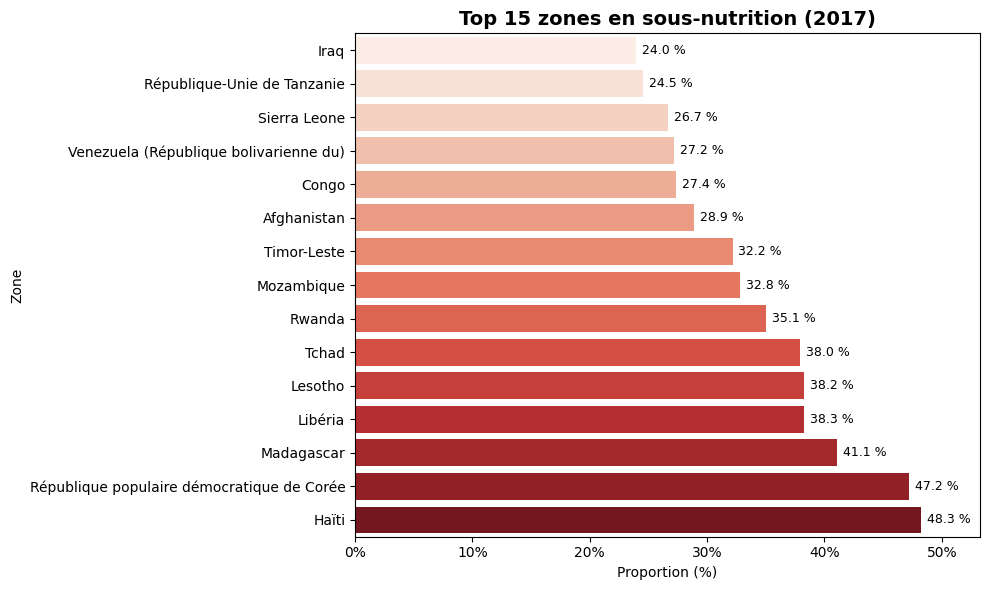

In [2624]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Copiez le DataFrame déjà filtré pour 2017
df_plot = pop_sousnutri_2017.copy()

# Convertir des proportions décimales en %
df_plot["proportion (%)"] = df_plot["proportion (%)"] * 1000

# Sélectionner les 15 zones présentant la plus forte proportion
df_plot = df_plot.nlargest(15, "proportion (%)").sort_values("proportion (%)", ascending=True)

# Créer le graphique
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_plot,
    x="proportion (%)",
    y="Zone",
    palette="Reds")

# Ajouter les valeurs à côté des barres
for i, v in enumerate(df_plot["proportion (%)"]):
    ax.text(v + 0.5, i, f"{v:.1f} %", color='black', va='center', fontsize=9)

# Titres et axes
plt.title("Top 15 zones en sous-nutrition (2017)", fontsize=14, weight='bold')
plt.xlabel("Proportion (%)")
plt.ylabel("Zone")

# Formater l'axe X en %
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
plt.xlim(0, df_plot["proportion (%)"].max() + 5)

plt.tight_layout()
plt.show()

In [2625]:
pop_sousnutri_2017["population"] = pd.to_numeric(
    pop_sousnutri_2017["population"], errors="coerce")

In [2626]:
total_population_millions = pop_sousnutri_2017["population"].sum()
total_sousnutri_millions = pop_sousnutri_2017["sous_nutrition"].sum()

In [2627]:
pourcentage_global = (total_sousnutri_millions / total_population_millions) * 100000

print(f"Population mondiale (2017): {total_population_millions:,.0f} millions")
print(f"Sous-nutrition totale (2017): {total_sousnutri_millions:,.0f} millions")
print(f"Proportion globale: {pourcentage_global:.2f}%")


Population mondiale (2017): 7,543,799 millions
Sous-nutrition totale (2017): 536 millions
Proportion globale: 7.10%


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

### Combien mange en moyenne un être humain ? (Source)

Selon les recommandations nutritionnelles, les besoins énergétiques journaliers moyens
pour un adulte sont approximativement :

- **2 600 kcal/jour** pour les hommes et **2 100 kcal/jour** pour les femmes  
  (source : [CERIN - Références nutritionnelles pour les adultes](https://www.cerin.org/articles/references-nutritionnelles-pour-les-adultes/))  

- **2 500 kcal/jour** pour les hommes et **2 000 kcal/jour** pour les femmes  
  (source : [NHS - Understanding healthy weight](https://www.nhsinform.scot/healthy-living/weight-loss/understanding-healthy-weight/))  

Pour simplifier les calculs dans cette étude, nous retiendrons une valeur moyenne de  
**2 300 kcal/jour par personne**.


In [2628]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population    
# Affichage des colonnes pour vérifier les noms exacts
print("Dispo colonnes:", dispo_alimentaire.columns.tolist())
print("Population colonnes:", population.columns.tolist())

Dispo colonnes: ['Zone', 'Produit', 'Origine', 'Aliments pour animaux', 'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité de matière grasse en quantité (g/personne/jour)', 'Disponibilité de protéines en quantité (g/personne/jour)', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Nourriture', 'Pertes', 'Production', 'Semences', 'Traitement', 'Variation de stock']
Population colonnes: ['Zone', 'Année', 'Valeur']


In [2629]:
# Partir du DataFrame population
# Filtrer uniquement l'année 2017
pop_2017 = population[population["Année"] == 2017].copy()

# Vérifier les colonnes
print(pop_2017.columns.tolist())

['Zone', 'Année', 'Valeur']


In [2630]:
#Affichage du nouveau dataframe
print(pop_2017.columns.tolist())

['Zone', 'Année', 'Valeur']


In [2631]:
# Copie propre des DataFrames bruts
dispo = dispo_alimentaire.copy()
pop = population.copy()

# Renommer la colonne kcal pour simplifier
dispo = dispo.rename(columns={
    "Disponibilité alimentaire (Kcal/personne/jour)": "dispo_kcal"})

# Ajouter l'année si manquante
if "Année" not in dispo.columns:
    dispo["Année"] = 2017

# Filtrer la population pour 2017
pop_2017 = pop.loc[pop["Année"] == 2017].copy()

In [2632]:
# Renommer la colonne 'Valeur' en 'Population'
pop_2017 = pop_2017.rename(columns={"Valeur": "Population"})

# Division par 1000 pour revenir aux individus
pop_2017.loc[:, "Population_corr"] = pop_2017["Population"] * 1000

# Vérification sur quelques pays
print(pop_2017.loc[pop_2017["Zone"].isin(["Afghanistan","France"]),["Zone","Population","Population_corr"]])

# Somme mondiale attendue ~7–8 milliards
print("Population mondiale en 2017 (corrigée) :", pop_2017["Population_corr"].sum())

            Zone  Population  Population_corr
4    Afghanistan   36296.113       36296113.0
424       France   64842.509       64842509.0
Population mondiale en 2017 (corrigée) : 7548134111.0


In [2633]:
# Agrégation par Zone–Année pour éviter les doublons par produit
kcal_zone = (
    dispo.groupby(["Zone","Année"], as_index=False)["dispo_kcal"].sum())

# Fusion avec la population corrigée
base = kcal_zone.merge(pop_2017[["Zone","Année","Population_corr"]],on=["Zone","Année"],how="inner").drop_duplicates(subset=["Zone","Année"])

print(base.head())

             Zone  Année  dispo_kcal  Population_corr
0     Afghanistan   2017      2087.0       36296113.0
1  Afrique du Sud   2017      3020.0       57009756.0
2         Albanie   2017      3188.0        2884169.0
3         Algérie   2017      3293.0       41389189.0
4       Allemagne   2017      3503.0       82658409.0


In [2634]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
# Kcal annuelles par zone
base["dispo_kcal_total"] = base["dispo_kcal"] * base["Population_corr"] * 365

# Besoin annuel par personne
besoin_annuel = 2300 * 365  # 839 500 kcal/an/personne

# Totaux mondiaux
dispo_kcal_monde_annuel = base["dispo_kcal_total"].sum()
nb_personnes_nourries = dispo_kcal_monde_annuel / besoin_annuel

print("Total mondial annuel de kcal disponibles :", dispo_kcal_monde_annuel)
print("Nombre théorique de personnes nourries en 2017 :", nb_personnes_nourries)

Total mondial annuel de kcal disponibles : 7635429388975815.0
Nombre théorique de personnes nourries en 2017 : 9095210707.535217


In [2635]:
#Calcul du nombre d'humains pouvant être nourris
pop_monde = base["Population_corr"].sum()
kcal_moyenne = dispo_kcal_monde_annuel / (pop_monde * 365)
ratio = nb_personnes_nourries / pop_monde

print("Population mondiale estimée :", pop_monde)                  # ~7–8e9
print("Disponibilité moyenne (kcal/hab/jour) :", kcal_moyenne)     # ~2000–3000
print("Ratio personnes nourries / population :", ratio)            # ~0.9–1.3

Population mondiale estimée : 7291900830.0
Disponibilité moyenne (kcal/hab/jour) : 2868.7971922584416
Ratio personnes nourries / population : 1.2473031270688877


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - GRAFIQUES Nombre théorique de personne qui pourrait être nourries</h3>
</div>

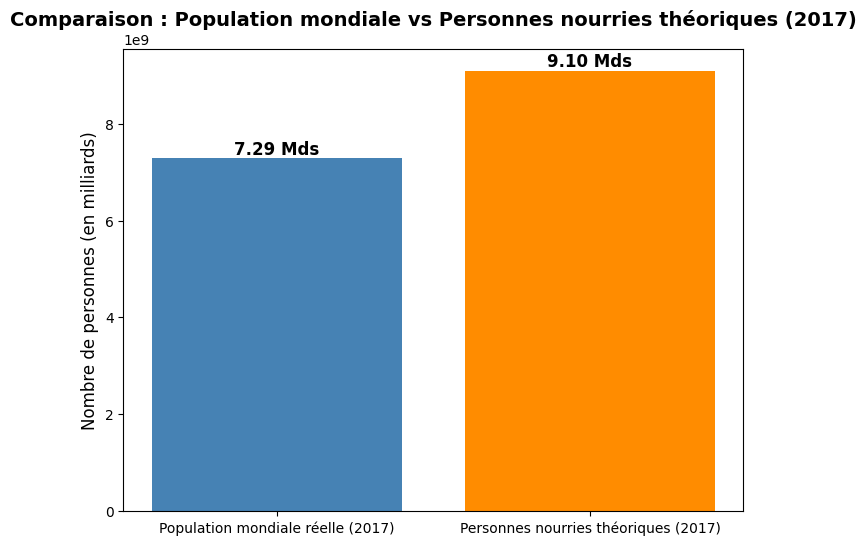

In [2636]:
import matplotlib.pyplot as plt

#  Valeurs
population_reelle = 7.29e9   # 7,29 milliards
personnes_nourries = 9.095e9 # ~9,1 milliards (resultado do cálculo)

#  Étiquettes et données
labels = ["Population mondiale réelle (2017)", "Personnes nourries théoriques (2017)"]
valeurs = [population_reelle, personnes_nourries]
couleurs = ["steelblue", "darkorange"]

#  Création du graphique
plt.figure(figsize=(8,6))
bars = plt.bar(labels, valeurs, color=couleurs)

#  Ajouter des valeurs au-dessus des barres
for bar, valeur in zip(bars, valeurs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{valeur/1e9:.2f} Mds", ha="center", va="bottom", fontsize=12, fontweight="bold")

#  Titre et axes
plt.title("Comparaison : Population mondiale vs Personnes nourries théoriques (2017)", fontsize=14, fontweight="bold")
plt.ylabel("Nombre de personnes (en milliards)", fontsize=12)

plt.show()


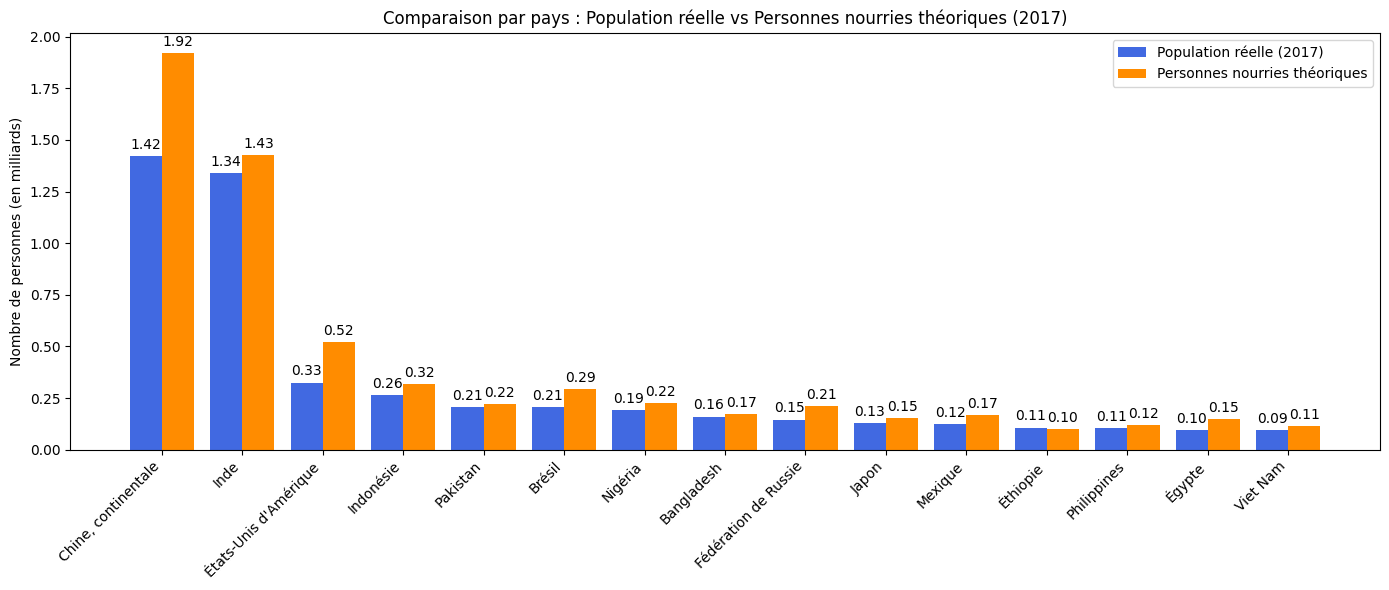

<Figure size 640x480 with 0 Axes>

In [2637]:
import numpy as np
import matplotlib.pyplot as plt


# Besoin annuel en kcal par personne
besoin_annuel = 2300 * 365  # 839 500 kcal/an/personne

# Calcul du nombre théorique de personnes nourries
base["personnes_nourries"] = base["dispo_kcal_total"] / besoin_annuel

# Sélection des 15 pays les plus peuplés
df_top15 = base.sort_values("Population_corr", ascending=False).head(15)

# Préparation des données
zones = df_top15["Zone"].tolist()
populations = df_top15["Population_corr"].values
nourries = df_top15["personnes_nourries"].values

# Conversion en milliards
pop_mds = populations / 1e9
nourries_mds = nourries / 1e9

# Positions des barres
x = np.arange(len(zones))
width = 0.4

# Création du graphique
fig, ax = plt.subplots(figsize=(14,6))
bar1 = ax.bar(x - width/2, pop_mds, width, label="Population réelle (2017)", color="royalblue")
bar2 = ax.bar(x + width/2, nourries_mds, width, label="Personnes nourries théoriques", color="darkorange")

# Labels et titre
ax.set_ylabel("Nombre de personnes (en milliards)")
ax.set_title("Comparaison par pays : Population réelle vs Personnes nourries théoriques (2017)")
ax.set_xticks(x)
ax.set_xticklabels(zones, rotation=45, ha="right")
ax.legend()

# Affichage des valeurs sur les barres
ax.bar_label(bar1, fmt="%.2f", padding=3)
ax.bar_label(bar2, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [2638]:
# Harmonisation des colonnes
dispo_alimentaire = dispo_alimentaire.rename(
    columns={"Disponibilité alimentaire (Kcal/personne/jour)": "dispo_kcal"})
population_clean = population.rename(columns={"Valeur": "Population"}).copy()

In [2639]:
# Fusion des disponibilites alimentaires avec la population (outer merge par Zone)
dispo_alimentaire_clean = dispo_alimentaire.merge(
    population_clean[["Zone", "Population"]],
    on="Zone",
    how="outer")

In [2640]:
# Transfert des donnees vegetales dans un nouveau dataframe
dispo_vegetaux = dispo_alimentaire_clean[dispo_alimentaire_clean["Origine"] == "vegetale"].copy()

In [2641]:
# Calcul du nombre de kcal disponibles pour les vegetaux
dispo_vegetaux["kcal_total_an"] = dispo_vegetaux["dispo_kcal"] * dispo_vegetaux["Population"] * 365
total_kcal_vegetaux = dispo_vegetaux["kcal_total_an"].sum()

In [2642]:
# Transfert des donnees vegetales dans un nouveau dataframe
dispo_vegetaux = dispo_alimentaire_clean[dispo_alimentaire_clean["Origine"] == "vegetale"].copy()

In [2643]:
# Calcul du nombre d humains pouvant etre nourris avec les vegetaux
besoin_annuel = 2300 * 365
personnes_nourries_vegetaux = total_kcal_vegetaux / besoin_annuel

print("Total kcal disponibles vegetaux :", int(total_kcal_vegetaux))
print("Nombre de personnes nourries theoriques vegetaux :", int(personnes_nourries_vegetaux))

Total kcal disponibles vegetaux : 37182605895568
Nombre de personnes nourries theoriques vegetaux : 44291370


In [2644]:
# Calcul du nombre d humains pouvant etre nourris avec le total des aliments
dispo_total = dispo_alimentaire_clean.copy()
dispo_total["kcal_total_an"] = dispo_total["dispo_kcal"] * dispo_total["Population"] * 365
total_kcal_total = dispo_total["kcal_total_an"].sum()

personnes_nourries_total = total_kcal_total / besoin_annuel

print("Total kcal disponibles (tous aliments) :", int(total_kcal_total))
print("Nombre de personnes nourries theoriques (tous aliments) :", int(personnes_nourries_total))

Total kcal disponibles (tous aliments) : 45095424170869
Nombre de personnes nourries theoriques (tous aliments) : 53717003


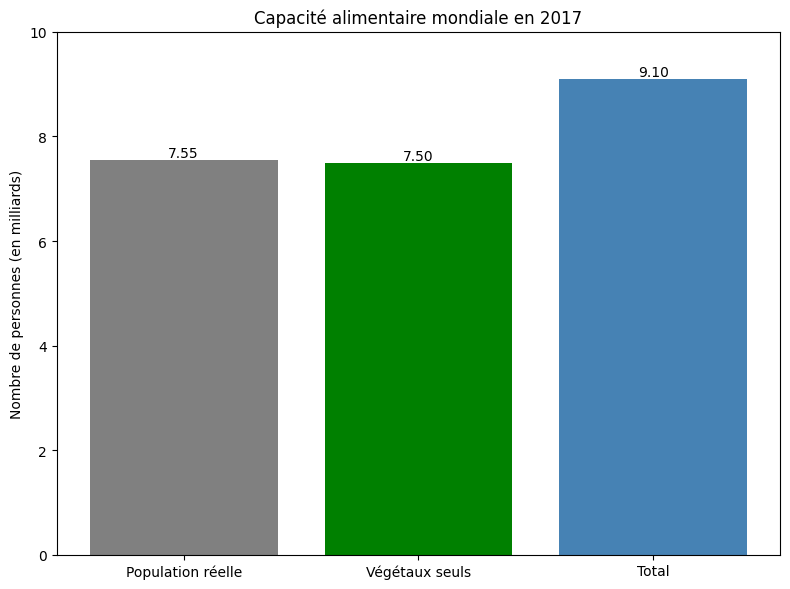

In [2645]:
import matplotlib.pyplot as plt

population_reelle = 7.55
nourries_vegetaux = 7.50
nourries_total = 9.10


categories = ["Population réelle", "Végétaux seuls", "Total"]
valeurs = [population_reelle, nourries_vegetaux, nourries_total]
couleurs = ["grey", "green", "steelblue"]

plt.figure(figsize=(8,6))
bars = plt.bar(categories, valeurs, color=couleurs)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,bar.get_height(),f"{bar.get_height():.2f}",ha="center", va="bottom", fontsize=10)

plt.ylabel("Nombre de personnes (en milliards)")
plt.title("Capacité alimentaire mondiale en 2017")
plt.ylim(0, 10)  # limite du graphique pour lisibilité
plt.tight_layout()
plt.show()

## Nombre théorique de personnes nourries par produits végétaux – par zone

🔎 **Points clés :**
- Ce graphique montre les 15 zones ayant la plus grande capacité théorique à nourrir des humains uniquement avec des produits végétaux.
- Les zones à forte population et/ou forte production agricole dominent le classement.
- Les chiffres représentent un potentiel nutritionnel, pas la consommation réelle.
- L’analyse par zone permet d’identifier les pays stratégiques dans la sécurité alimentaire mondiale.

📌 **Méthodologie :**
- Filtrage des données pour ne garder que les produits d’origine végétale.
- Calcul des kilocalories disponibles × population.
- Conversion en nombre théorique de personnes nourries (base 2 300 kcal/jour).
- Agrégation par zone et sélection des 15 premières.

In [2646]:
#GRAPHIQUES PAR ZONE
# Creation du dataframe par pays
dispo_pays = dispo_alimentaire_clean.groupby("Zone", as_index=False).agg({
    "Population": "max",   # population par pays
    "dispo_kcal": "mean"   # kcal moyen par personne/jour
})

In [2647]:
# Calcul du nombre de kcal disponibles par pays
dispo_pays["kcal_total_an"] = dispo_pays["dispo_kcal"] * dispo_pays["Population"] * 365

In [2648]:
# Calcul du nombre d humains pouvant etre nourris par pays
besoin_annuel = 2300 * 365
dispo_pays["personnes_nourries"] = dispo_pays["kcal_total_an"] / besoin_annuel

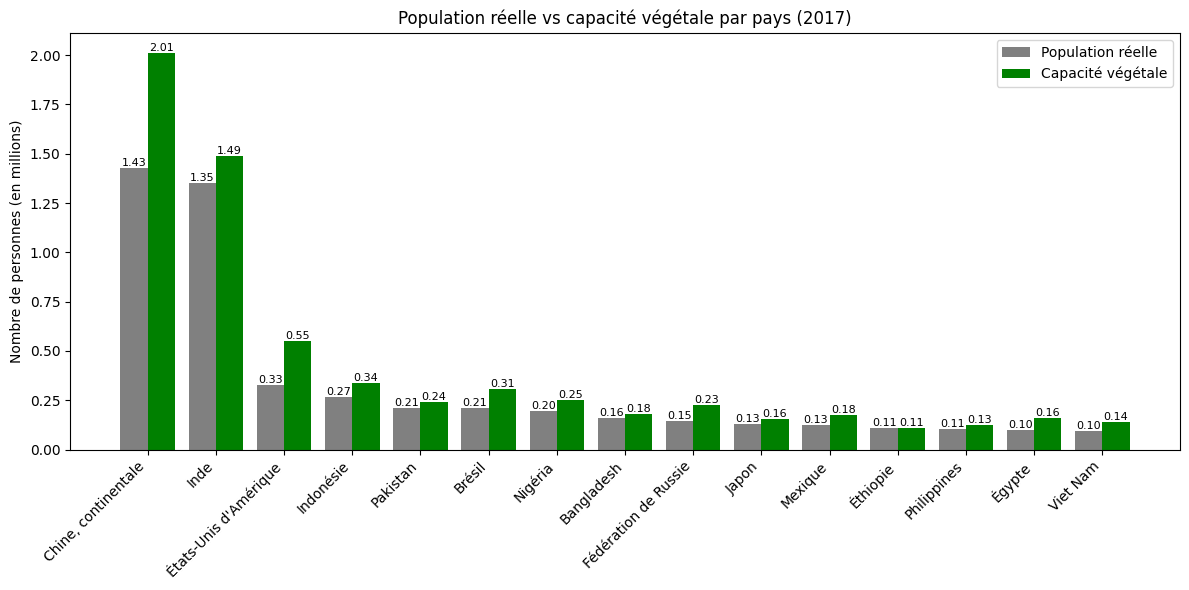

In [2649]:
# Graphique par pays

# 15 pays les plus peuplés
top_pays = dispo_pays.sort_values("Population", ascending=False).head(15)

pays = top_pays["Zone"]
populations = top_pays["Population"] / 1e6
capacites = top_pays["personnes_nourries"] /1e4

plt.figure(figsize=(12,6))
bar_width = 0.4
x = np.arange(len(pays))

bars_pop = plt.bar(x - bar_width/2, populations, width=bar_width, label="Population réelle", color="gray")
bars_cap = plt.bar(x + bar_width/2, capacites, width=bar_width, label="Capacité végétale", color="green")

plt.xticks(x, pays, rotation=45, ha="right")
plt.ylabel("Nombre de personnes (en millions)")
plt.title("Population réelle vs capacité végétale par pays (2017)")
plt.legend()

# Labels
for bar in bars_pop:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars_cap:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [2650]:
df_dispo = pd.read_csv("dispo_alimentaire.csv")
print(df_dispo.columns.tolist())

['Zone', 'Produit', 'Origine', 'Aliments pour animaux', 'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité de matière grasse en quantité (g/personne/jour)', 'Disponibilité de protéines en quantité (g/personne/jour)', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Nourriture', 'Pertes', 'Production', 'Semences', 'Traitement', 'Variation de stock']


In [2651]:
#Calcul de la disponibilité totale
df_dispo["Disponibilité intérieure"] = pd.to_numeric(df_dispo["Disponibilité intérieure"], errors="coerce").fillna(0)

dispo_totale = df_dispo["Disponibilité intérieure"].sum()

print(f"Disponibilité intérieure totale : {dispo_totale:.0f}")

Disponibilité intérieure totale : 9848994


In [2652]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 

# Chargement des données
df_dispo = pd.read_csv("dispo_alimentaire.csv")

# 1) Calcul de la disponibilité intérieure totale
df_dispo["Disponibilité intérieure"] = pd.to_numeric(
    df_dispo["Disponibilité intérieure"], errors="coerce").fillna(0)

dispo_totale = df_dispo["Disponibilité intérieure"].sum()
print(f"Disponibilité intérieure totale : {dispo_totale:.0f}\n")

# 2) Colonnes représentant les utilisations que l'on veut analyser
colonnes_utilisation = [
    "Aliments pour animaux",
    "Pertes",
    "Nourriture"]

# On s'assure que ces colonnes sont bien numériques
for col in colonnes_utilisation:
    df_dispo[col] = pd.to_numeric(df_dispo[col], errors="coerce").fillna(0)

# 3) Boucle for pour afficher les totaux et les pourcentages
print("Utilisation de la disponibilité intérieure :\n")

for col in colonnes_utilisation:
    total_col = df_dispo[col].sum()
    part_col = (total_col / dispo_totale) * 100 if dispo_totale != 0 else 0

    print(
        f"- {col} : {total_col:.0f} "
        f"({part_col:.2f} % de la disponibilité intérieure)")


Disponibilité intérieure totale : 9848994

Utilisation de la disponibilité intérieure :

- Aliments pour animaux : 1304245 (13.24 % de la disponibilité intérieure)
- Pertes : 453698 (4.61 % de la disponibilité intérieure)
- Nourriture : 4876258 (49.51 % de la disponibilité intérieure)


Disponibilité intérieure totale : 9848994 (milliers de tonnes)


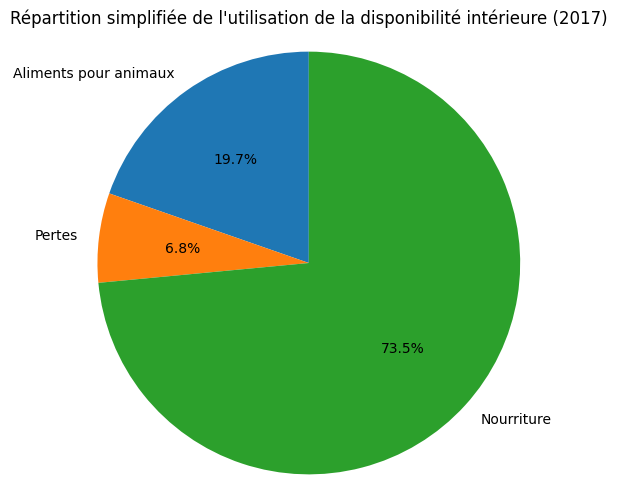

In [2653]:
# Disponibilité intérieure en milliers de tonnes
df_dispo["Disponibilité intérieure"] = pd.to_numeric(
    df_dispo["Disponibilité intérieure"], errors="coerce").fillna(0)

dispo_totale = df_dispo["Disponibilité intérieure"].sum()
print(f"Disponibilité intérieure totale : {dispo_totale:.0f} (milliers de tonnes)")

# Colonnes d'utilisation à analyser
colonnes_utilisation = [
    "Aliments pour animaux",
    "Pertes",
    "Nourriture"]

# On s'assure que ces colonnes sont bien numériques
for col in colonnes_utilisation:
    df_dispo[col] = pd.to_numeric(df_dispo[col], errors="coerce").fillna(0)

# === 1) Répartition simplifiée (3 catégories) ===
totaux_simplifies = {col: df_dispo[col].sum() for col in colonnes_utilisation}

labels_simplifie = list(totaux_simplifies.keys())
valeurs_simplifie = list(totaux_simplifies.values())

plt.figure(figsize=(6, 6))
plt.pie(
    valeurs_simplifie,
    labels=labels_simplifie,
    autopct='%1.1f%%',
    startangle=90)

plt.title("Répartition simplifiée de l'utilisation de la disponibilité intérieure (2017)")
plt.axis('equal')  # pour un camembert bien rond
plt.show()


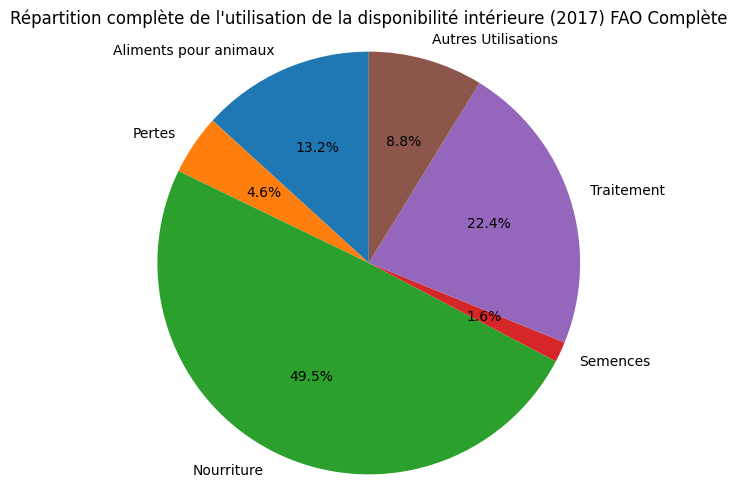

In [2654]:
# Répartition complète : toutes les utilisations de la disponibilité intérieure
colonnes_completes = [
    "Aliments pour animaux",
    "Pertes",
    "Nourriture",
    "Semences",
    "Traitement",
    "Autres Utilisations"]

totaux_complets = df_dispo[colonnes_completes].sum()

plt.figure(figsize=(6, 6))
plt.pie(
    totaux_complets.values,
    labels=totaux_complets.index,
    autopct='%1.1f%%',
    startangle=90)

plt.title("Répartition complète de l'utilisation de la disponibilité intérieure (2017) FAO Complète")
plt.axis('equal')
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [2655]:
# Création d'une liste avec toutes les variables d'utilisation
# Liste complète des produits céréaliers
liste_cereales = [
    "Avoine",
    "Blé",
    "Céréales, Autres",
    "Maïs",
    "Millet",
    "Orge",
    "Riz (Eq Blanchi)",
    "Seigle",
    "Sorgho"]

#Création d'un dataframe avec les informations uniquement pour ces céréales
df_cereales = dispo_alimentaire[dispo_alimentaire["Produit"].isin(liste_cereales)].copy()

#Calculer les sommes absolues
total_nourriture = df_cereales["Nourriture"].sum()
total_animaux = df_cereales["Aliments pour animaux"].sum()

#Calculer le total et les proportions
total_cereales = total_nourriture + total_animaux
prop_nourriture = total_nourriture / total_cereales * 100
prop_animaux = total_animaux / total_cereales * 100

# #Affichage de la proportion d'alimentation animale et humaine
print("Répartition globale (céréales uniquement) :")
print(f"Alimentation humaine : {prop_nourriture:.1f} % ({total_nourriture:.0f} unités)")
print(f"Alimentation animale : {prop_animaux:.1f} % ({total_animaux:.0f} unités)")

Répartition globale (céréales uniquement) :
Alimentation humaine : 54.1 % (1029010000000 unités)
Alimentation animale : 45.9 % (873535000000 unités)


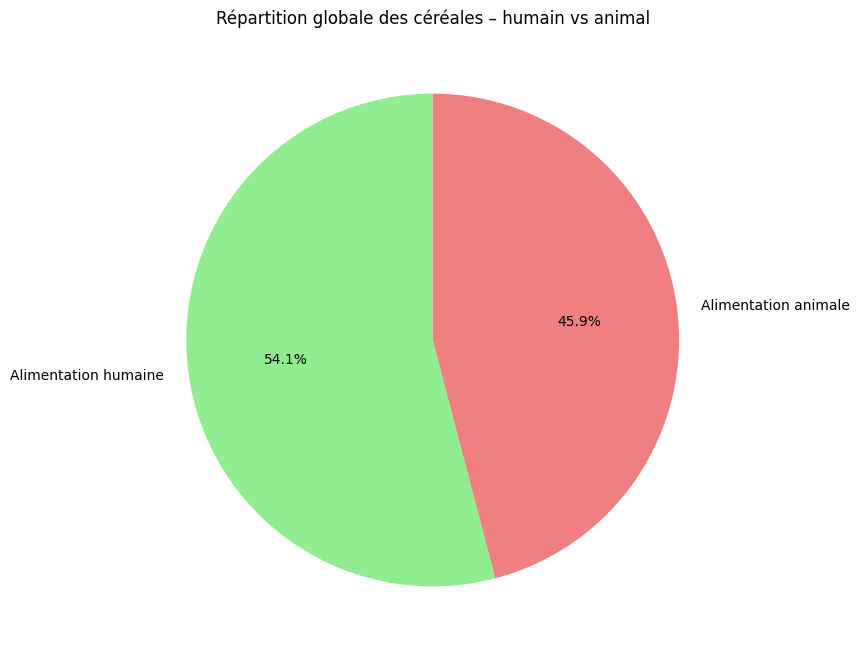

In [2656]:
#Utilisation de céréales (GRAPHIQUES)

# Étape 3 : créer le graphique en camembert
plt.figure(figsize=(8,8))
plt.pie(
    [total_nourriture, total_animaux],
    labels=["Alimentation humaine", "Alimentation animale"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["lightgreen", "lightcoral"])

# Étape 4 : ajouter le titre
plt.title("Répartition globale des céréales – humain vs animal")

plt.show()

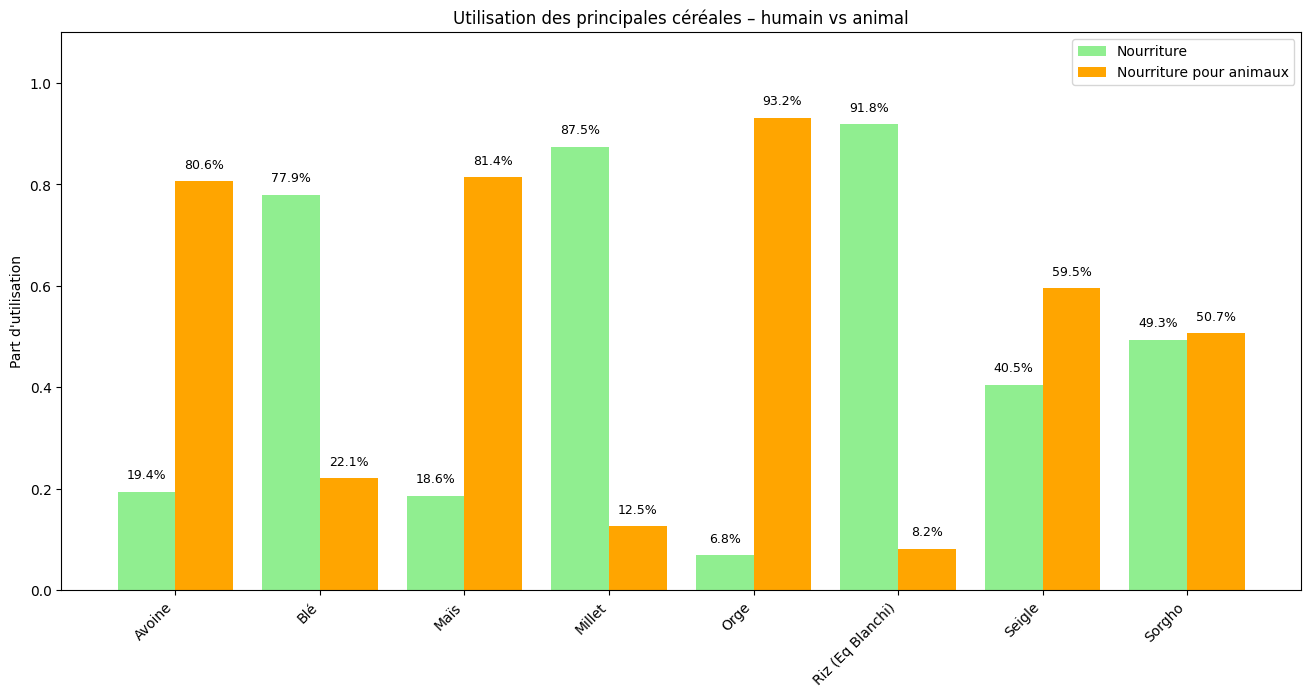

In [2657]:
#Utilisation de céréales (GRAPHIQUE PAR CÉRÉALES)
# Définir la liste des céréales principales
cereales = ["Blé", "Riz (Eq Blanchi)", "Orge", "Maïs", "Seigle",
            "Avoine", "Millet", "Sorgho", "Céréales", "Autres"]

# Filtrer le dataframe
df_cereales = df[df["Produit"].isin(cereales)].copy()

# Forcer les colonnes en numérique
df_cereales["Nourriture"] = pd.to_numeric(df_cereales["Nourriture"], errors="coerce")
df_cereales["Aliments pour animaux"] = pd.to_numeric(df_cereales["Aliments pour animaux"], errors="coerce")

# Regrouper par produit
df_grouped = df_cereales.groupby("Produit")[["Nourriture", "Aliments pour animaux"]].sum().reset_index()

# Calculer le total et les parts
df_grouped["Total"] = df_grouped["Nourriture"] + df_grouped["Aliments pour animaux"]
df_grouped = df_grouped[df_grouped["Total"] > 0]  # éviter division par zéro

df_grouped["Part_nourriture"] = df_grouped["Nourriture"] / df_grouped["Total"]
df_grouped["Part_animaux"] = df_grouped["Aliments pour animaux"] / df_grouped["Total"]

# Préparer les données
produits = df_grouped["Produit"].to_numpy()
nourriture = df_grouped["Part_nourriture"].to_numpy()
animaux = df_grouped["Part_animaux"].to_numpy()
x = np.arange(len(produits))

# Tracer le graphique
plt.figure(figsize=(16,9))
plt.bar(x - 0.2, nourriture, width=0.4, label="Nourriture", color="lightgreen")
plt.bar(x + 0.2, animaux, width=0.4, label="Nourriture pour animaux", color="orange")

plt.xticks(x, produits, rotation=45, ha="right", fontsize=10)
plt.ylabel("Part d'utilisation")
plt.title("Utilisation des principales céréales – humain vs animal")
plt.legend()

# Ajouter les labels en pourcentage
for i in range(len(produits)):
    plt.text(x[i] - 0.2, nourriture[i] + 0.02, f"{nourriture[i]*100:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.text(x[i] + 0.2, animaux[i] + 0.02, f"{animaux[i]*100:.1f}%", ha="center", va="bottom", fontsize=9)

plt.ylim(0, 1.1)
plt.subplots_adjust(bottom=0.28, top=0.9)
plt.show()

Toutes les céréales présentes dans la base FAO ont été incluses dans le calcul.
Outre les huit principales (Blé, Riz, Maïs, Orge, Seigle, Avoine, Millet, Sorgho), la catégorie Céréales, autres couvre les produits marginaux (Triticale, Fonio, Épeautre, Sarrasin). Leur contribution est négligeable, mais ils sont comptabilisés pour assurer l’exhaustivité.

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [2658]:
print(pop_sousnutri_2017.columns)

Index(['Zone', 'Année', 'population', 'sous_nutrition', 'proportion (%)'], dtype='object')


In [2659]:
# Création de la colonne proportion par pays
pop_sousnutri_2017["Proportion_sous_alimentee"] = (
    pop_sousnutri_2017["sous_nutrition"] / pop_sousnutri_2017["population"] * 100
)

# Tri décroissant par proportion
df_sorted = pop_sousnutri_2017.sort_values(by="Proportion_sous_alimentee", ascending=False)

# Affichage des 10 pires pays
top10_pires = df_sorted.head(10)
print(top10_pires[["Zone","Proportion_sous_alimentee"]])

                                           Zone  Proportion_sous_alimentee
78                                        Haïti                   0.048259
157  République populaire démocratique de Corée                   0.047189
108                                  Madagascar                   0.041063
103                                     Libéria                   0.038280
100                                     Lesotho                   0.038249
183                                       Tchad                   0.037958
161                                      Rwanda                   0.035056
121                                  Mozambique                   0.032811
186                                 Timor-Leste                   0.032174
0                                   Afghanistan                   0.028929


In [2660]:
# Réutiliser la colonne déjà existante "proportion (%)" # Ici, nous utilisons le DataFrame déjà existant : pop_sousnutri_2017

# Trier par proportion décroissante
df_sorted = pop_sousnutri_2017.sort_values(by="proportion (%)", ascending=False)

# Sélectionner les 10 pires pays
top10_pires = df_sorted.head(10)

# Affichage
print(top10_pires[["Zone","proportion (%)"]])

                                           Zone  proportion (%)
78                                        Haïti        0.048259
157  République populaire démocratique de Corée        0.047189
108                                  Madagascar        0.041063
103                                     Libéria        0.038280
100                                     Lesotho        0.038249
183                                       Tchad        0.037958
161                                      Rwanda        0.035056
121                                  Mozambique        0.032811
186                                 Timor-Leste        0.032174
0                                   Afghanistan        0.028929


In [2661]:
# La colonne 'proportion (%)' est actuellement en fraction (ex: 0.048 = 4,8 %)
# Nous la convertissons en pourcentage lisible

pop_sousnutri_2017["proportion (%)"] = pop_sousnutri_2017["proportion (%)"] * 100
pop_sousnutri_2017["proportion (%)"] = pop_sousnutri_2017["proportion (%)"].round(2)

# Tri décroissant par proportion
df_sorted = pop_sousnutri_2017.sort_values(by="proportion (%)", ascending=False)


In [2662]:
# df_sorted 
top10_pires = df_sorted.head(10).reset_index(drop=True)

# Coluna Rang (1 a 10)
top10_pires["Rang"] = top10_pires.index + 1

# Renommer les colonnes pour l'affichage
top10_affichage = top10_pires.rename(columns={
    "Zone": "Pays",
    "proportion (%)": "Proportion (%)"})

#Conversion de la fraction en % ***
top10_affichage["Proportion (%)"] = (
    top10_affichage["Proportion (%)"] * 10).round(1)   # 48.3 etc.

# Réorganiser les colonnes
top10_affichage = top10_affichage[["Rang", "Pays", "Proportion (%)"]]

print(top10_affichage)


   Rang                                        Pays  Proportion (%)
0     1                                       Haïti            48.3
1     2  République populaire démocratique de Corée            47.2
2     3                                  Madagascar            41.1
3     4                                     Libéria            38.3
4     5                                     Lesotho            38.2
5     6                                       Tchad            38.0
6     7                                      Rwanda            35.1
7     8                                  Mozambique            32.8
8     9                                 Timor-Leste            32.2
9    10                                 Afghanistan            28.9


In [2663]:
# Trier par proportion décroissante
df_sorted = pop_sousnutri_2017.sort_values(by="Proportion_sous_alimentee", ascending=False)

# Sélectionner les 10 pires pays
top10_pays_pct = df_sorted.set_index("Zone")["Proportion_sous_alimentee"].head(10)

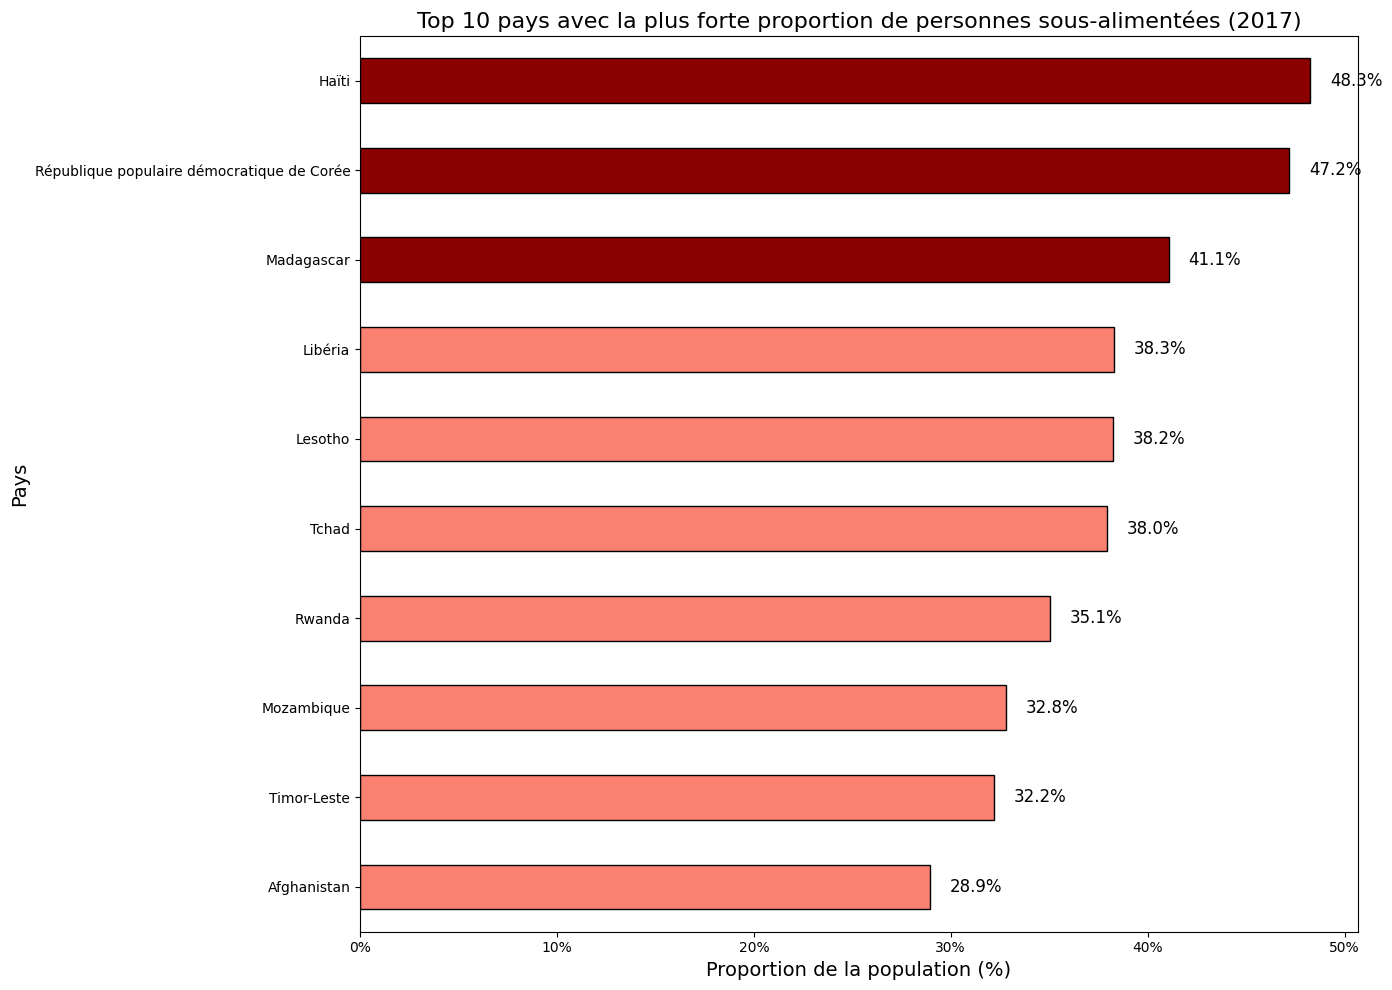

In [2664]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Étape 1 : trier et sélectionner les 10 pires pays
df_sorted = pop_sousnutri_2017.sort_values(by="Proportion_sous_alimentee", ascending=False)
top10_pays_pct = df_sorted.set_index("Zone")["Proportion_sous_alimentee"].head(10) * 1000  # en %

# Étape 2 : définir les pays à surligner
pays_a_surligner = ["Haïti", "République populaire démocratique de Corée", "Madagascar"]

# Étape 3 : créer la liste de couleurs
couleurs = ["darkred" if pays in pays_a_surligner else "salmon" for pays in top10_pays_pct.index]

# Étape 4 : créer le graphique en barres horizontales
fig, ax = plt.subplots(figsize=(14,10))  # taille plus grande
top10_pays_pct.plot(kind="barh", color=couleurs, edgecolor="black", ax=ax)

# Étape 5 : personnaliser le titre et les axes
ax.set_title("Top 10 pays avec la plus forte proportion de personnes sous-alimentées (2017)", fontsize=16)
ax.set_xlabel("Proportion de la population (%)", fontsize=14)
ax.set_ylabel("Pays", fontsize=14)

# Étape 6 : formatage de l’axe X en pourcentage
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

# Étape 7 : inverser l’axe Y pour avoir le plus fort en haut
ax.invert_yaxis()

# Étape 8 : ajouter les labels en pourcentage à côté des barres
for i, valeur in enumerate(top10_pays_pct):
    ax.text(valeur + 1, i, f"{valeur:.1f}%", va="center", fontsize=12)

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [2665]:
#calcul du total de l'aide alimentaire par pays

import pandas as pd

aide_alimentaire = pd.read_csv("aide_alimentaire.csv")
print(aide_alimentaire.columns)


Index(['Pays bénéficiaire', 'Année', 'Produit', 'Valeur'], dtype='object')


In [2666]:
print(aide_alimentaire.columns.tolist())


['Pays bénéficiaire', 'Année', 'Produit', 'Valeur']


In [2667]:
aide_par_pays = aide_alimentaire.groupby("Pays bénéficiaire")["Valeur"].sum().reset_index()
print(aide_par_pays.head())


  Pays bénéficiaire  Valeur
0       Afghanistan  185452
1           Algérie   81114
2            Angola    5014
3        Bangladesh  348188
4           Bhoutan    2666


In [2668]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire

top_10_aide = aide_par_pays.sort_values(by="Valeur", ascending=False).head(10).reset_index(drop=True)
print(top_10_aide)


                  Pays bénéficiaire   Valeur
0         République arabe syrienne  1858943
1                          Éthiopie  1381294
2                             Yémen  1206484
3                     Soudan du Sud   695248
4                            Soudan   669784
5                             Kenya   552836
6                        Bangladesh   348188
7                           Somalie   292678
8  République démocratique du Congo   288502
9                             Niger   276344


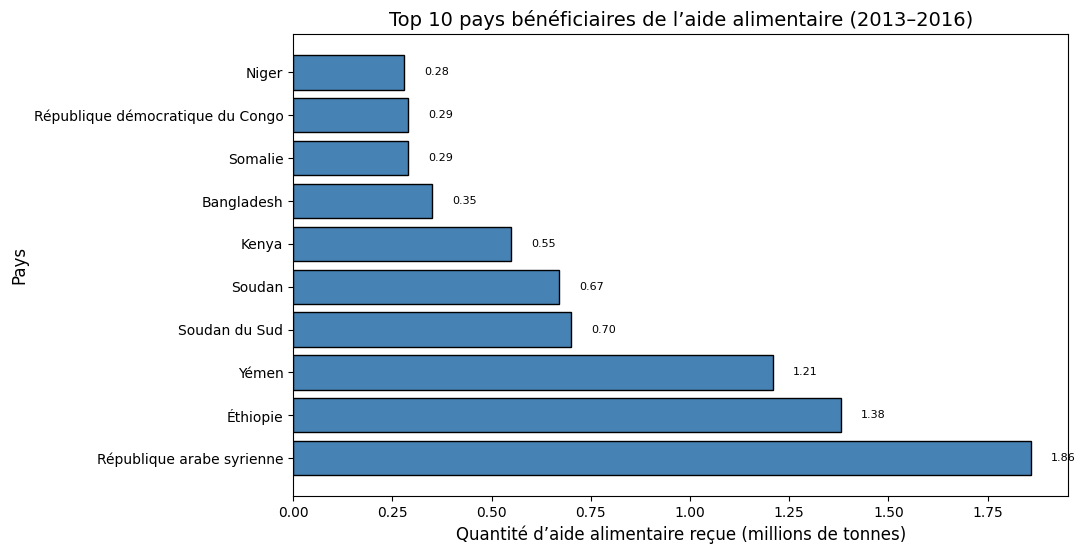

In [2669]:
import matplotlib.pyplot as plt

# le DataFrame s'appelle top_10_aide
# Il contient deux colonnes : "Pays bénéficiaire" et "Valeur"

fig, ax = plt.subplots(figsize=(10,6))

# Conversion en millions de tonnes avec deux décimales pour aligner avec l’axe X
top_10_aide_sorted = top_10_aide.sort_values("Valeur", ascending=True)
top_10_aide_sorted["Valeur"] = (top_10_aide_sorted["Valeur"] / 1_000_000).round(2)

# Créer le graphique en barres horizontales
ax.barh(top_10_aide_sorted["Pays bénéficiaire"], 
        top_10_aide_sorted["Valeur"], 
        color="steelblue", edgecolor="black")

# Ajouter le titre et les labels des axes
ax.set_title("Top 10 pays bénéficiaires de l’aide alimentaire (2013–2016)", fontsize=14)
ax.set_xlabel("Quantité d’aide alimentaire reçue (millions de tonnes)", fontsize=12)
ax.set_ylabel("Pays", fontsize=12)

# Inverser l’axe Y pour que le pays avec la plus grande valeur soit en haut
ax.invert_yaxis()

# Ajouter les valeurs exactes à droite des barres
for i, v in enumerate(top_10_aide_sorted["Valeur"]):
    ax.text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=8)

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [2670]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
aide_2013_2016 = aide_alimentaire[(aide_alimentaire["Année"] >= 2013) & (aide_alimentaire["Année"] <= 2016)]


In [2671]:
aide_groupée = aide_2013_2016.groupby(["Pays bénéficiaire", "Année"])["Valeur"].sum().reset_index()
print(aide_groupée.head())


  Pays bénéficiaire  Année  Valeur
0       Afghanistan   2013  128238
1       Afghanistan   2014   57214
2           Algérie   2013   35234
3           Algérie   2014   18980
4           Algérie   2015   17424


In [2672]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
top_5_pays = aide_2013_2016.groupby("Pays bénéficiaire")["Valeur"].sum().sort_values(ascending=False).head(5).index.tolist()
print(top_5_pays)


['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']


In [2673]:
#On filtre sur le dataframe avec notre liste
aide_top5 = aide_groupée[aide_groupée["Pays bénéficiaire"].isin(top_5_pays)]
print(aide_top5.head())


             Pays bénéficiaire  Année  Valeur
157  République arabe syrienne   2013  563566
158  République arabe syrienne   2014  651870
159  République arabe syrienne   2015  524949
160  République arabe syrienne   2016  118558
189                     Soudan   2013  330230


In [2674]:
# Affichage des pays avec l'aide alimentaire par année
table_evolution = aide_top5.pivot(index="Année", columns="Pays bénéficiaire", values="Valeur")
table_evolution = table_evolution.reindex(columns=top_5_pays)
table_evolution = table_evolution.fillna(0).astype(int)
print(table_evolution.to_string())




Pays bénéficiaire  République arabe syrienne  Éthiopie   Yémen  Soudan du Sud  Soudan
Année                                                                                
2013                                  563566    591404  264764         196330  330230
2014                                  651870    586624  103840         450610  321904
2015                                  524949    203266  372306          48308   17650
2016                                  118558         0  465574              0       0


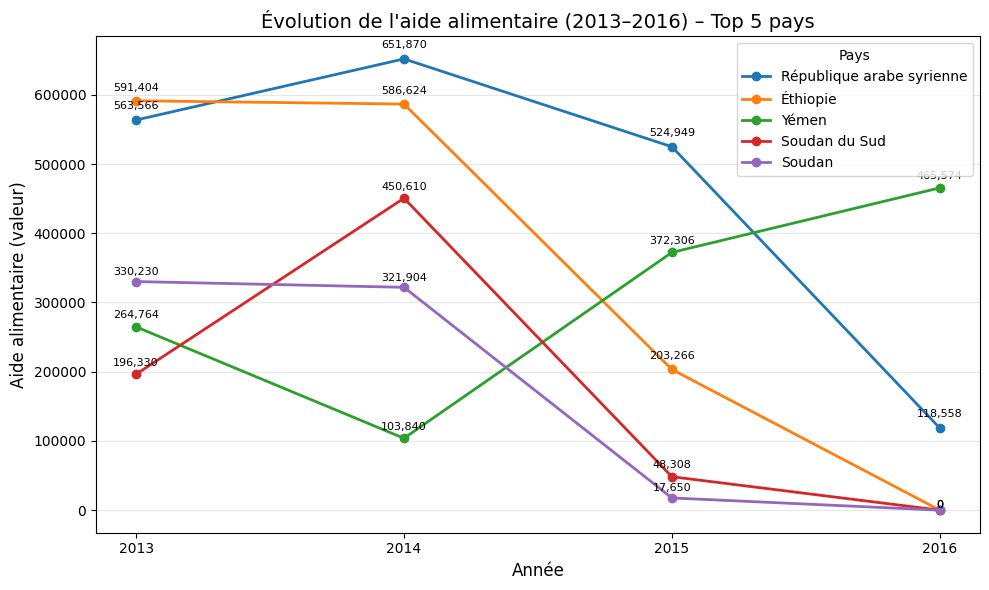

In [2675]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))


for country in table_evolution.columns:
    x = table_evolution.index
    y = table_evolution[country]
    plt.plot(x, y, marker="o", linewidth=2, label=country)

     # Ajouter des étiquettes numériques sur chaque point
    for xi, yi in zip(x, y):
        plt.text(xi, yi + (max(y)*0.02 if yi > 0 else 0), f"{yi:,}", 
                 ha="center", va="bottom", fontsize=8)

plt.title("Évolution de l'aide alimentaire (2013–2016) – Top 5 pays", fontsize=14)
plt.xlabel("Année", fontsize=12)
plt.ylabel("Aide alimentaire (valeur)", fontsize=12)
plt.grid(True, axis="y", alpha=0.3)
plt.legend(title="Pays", fontsize=10)
plt.xticks(table_evolution.index)

plt.tight_layout()
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [2676]:
#Calcul de la disponibilité en kcal par personne par jour par pays
import pandas as pd

# On part du dataframe df_dispo déjà chargé
# df_dispo = pd.read_csv("dispo_alimentaire.csv")

# 1) S'assurer que la colonne de kcal est bien numérique
df_dispo["Disponibilité alimentaire (Kcal/personne/jour)"] = pd.to_numeric(
    df_dispo["Disponibilité alimentaire (Kcal/personne/jour)"], 
    errors="coerce"
).fillna(0)

# 2) Calcul de la disponibilité totale en kcal/personne/jour par pays
dispo_kcal_pays = (
    df_dispo
    .groupby("Zone", as_index=False)["Disponibilité alimentaire (Kcal/personne/jour)"]
    .sum()
    .rename(columns={
        "Disponibilité alimentaire (Kcal/personne/jour)": 
        "dispo_kcal_pers_jour"}))

# Juste pour vérifier le début du tableau
dispo_kcal_pays.head()

,Zone,dispo_kcal_pers_jour
0,Afghanistan,2087.0
1,Afrique du Sud,3020.0
2,Albanie,3188.0
3,Algérie,3293.0
4,Allemagne,3503.0


In [2677]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne
# Tri croissant sur la disponibilité en kcal/personne/jour
dispo_kcal_pays_10_min = (
    dispo_kcal_pays
    .sort_values("dispo_kcal_pers_jour", ascending=True)
    .head(11))

print("Les 10 pays ayant la plus faible disponibilité alimentaire (kcal/personne/jour) :")
dispo_kcal_pays_10_min

Les 10 pays ayant la plus faible disponibilité alimentaire (kcal/personne/jour) :


,Zone,dispo_kcal_pers_jour
128,République centrafricaine,1879.0
166,Zambie,1924.0
91,Madagascar,2056.0
0,Afghanistan,2087.0
65,Haïti,2089.0
133,République populaire démocratique de Corée,2093.0
151,Tchad,2109.0
167,Zimbabwe,2113.0
114,Ouganda,2126.0
172,Éthiopie,2129.0


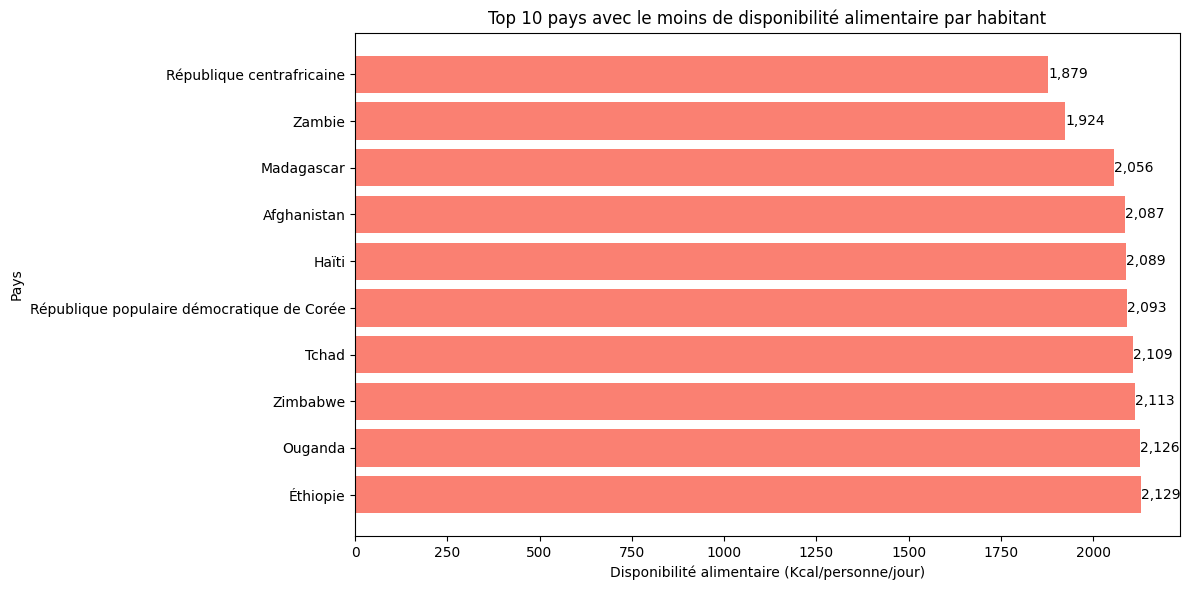

In [2678]:

# Calcul de la dispo kcal/personne/jour par pays
df_dispo = pd.read_csv("dispo_alimentaire.csv")

df_dispo["Disponibilité alimentaire (Kcal/personne/jour)"] = pd.to_numeric(
    df_dispo["Disponibilité alimentaire (Kcal/personne/jour)"],
    errors="coerce").fillna(0)

dispo_kcal_pays = (
    df_dispo
    .groupby("Zone", as_index=False)["Disponibilité alimentaire (Kcal/personne/jour)"]
    .sum()
    .rename(columns={"Disponibilité alimentaire (Kcal/personne/jour)": "dispo_kcal_pers_jour"}))

# Top 10 pays avec le moins de disponibilité
top10_min = (
    dispo_kcal_pays
    .sort_values("dispo_kcal_pers_jour", ascending=True)
    .head(10))

# Graphique en barres horizontales 
plt.figure(figsize=(12, 6))

plt.barh(
    top10_min["Zone"],
    top10_min["dispo_kcal_pers_jour"],
    color="salmon")

plt.xlabel("Disponibilité alimentaire (Kcal/personne/jour)")
plt.ylabel("Pays")
plt.title("Top 10 pays avec le moins de disponibilité alimentaire par habitant")

plt.gca().invert_yaxis()

for i, val in enumerate(top10_min["dispo_kcal_pers_jour"]):
    plt.text(
        val,
        i,
        f"{val:,.0f}",
        va="center",
        ha="left",
        fontsize=10)

plt.tight_layout()
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

Les 10 pays ayant la plus forte disponibilité alimentaire (kcal/personne/jour) :


,Zone,dispo_kcal_pers_jour
11,Autriche,3770.0
16,Belgique,3737.0
159,Turquie,3708.0
171,États-Unis d'Amérique,3682.0
74,Israël,3610.0
72,Irlande,3602.0
75,Italie,3578.0
89,Luxembourg,3540.0
168,Égypte,3518.0
4,Allemagne,3503.0


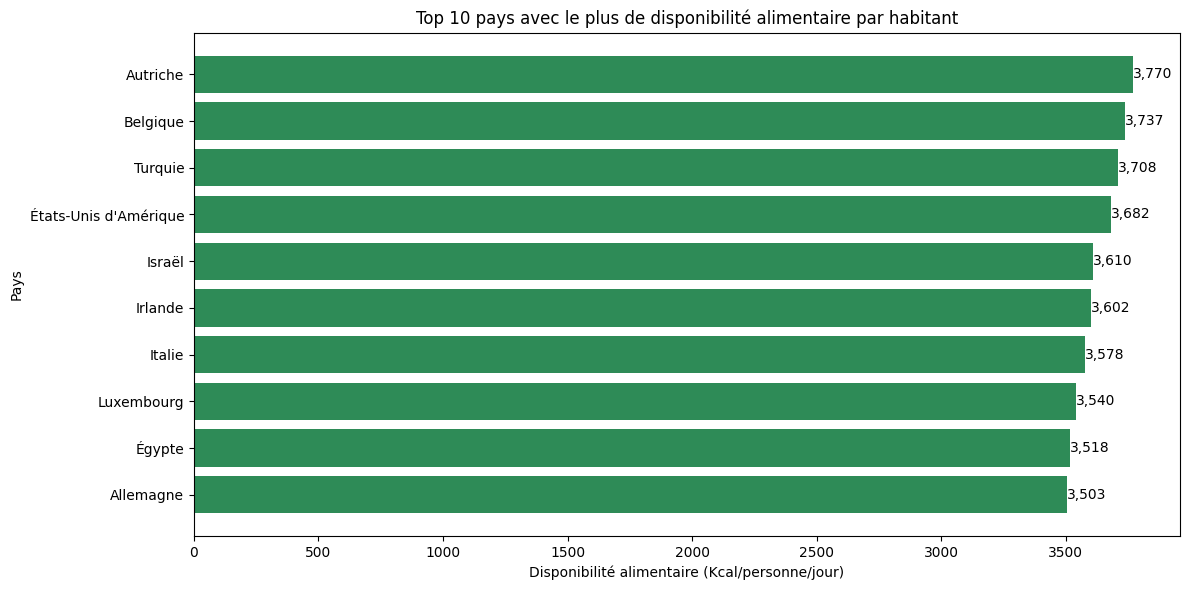

In [2679]:
# =========================================================
# Calcul de la disponibilité en kcal par personne par jour par pays
# =========================================================

# On s'assure que la colonne de kcal est bien numérique
df_dispo["Disponibilité alimentaire (Kcal/personne/jour)"] = pd.to_numeric(
    df_dispo["Disponibilité alimentaire (Kcal/personne/jour)"],
    errors="coerce").fillna(0)

# Agrégation par pays (Zone)
dispo_kcal_pays = (
    df_dispo
    .groupby("Zone", as_index=False)["Disponibilité alimentaire (Kcal/personne/jour)"]
    .sum()
    .rename(columns={"Disponibilité alimentaire (Kcal/personne/jour)": "dispo_kcal_pers_jour"})
)

# =========================================================
# Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
# =========================================================

# Tri décroissant et sélection des 10 premiers
top10_max = (
    dispo_kcal_pays
    .sort_values("dispo_kcal_pers_jour", ascending=False)
    .head(10))

print("Les 10 pays ayant la plus forte disponibilité alimentaire (kcal/personne/jour) :")
display(top10_max)

# =========================================================
# Visualisation : graphique en barres horizontales (camembert style ranking)
# =========================================================

plt.figure(figsize=(12, 6))

plt.barh(
    top10_max["Zone"],
    top10_max["dispo_kcal_pers_jour"],
    color="seagreen")

plt.xlabel("Disponibilité alimentaire (Kcal/personne/jour)")
plt.ylabel("Pays")
plt.title("Top 10 pays avec le plus de disponibilité alimentaire par habitant")

# On inverse l'axe Y pour avoir le pays le plus doté en haut
plt.gca().invert_yaxis()

# Ajout des valeurs numériques au bout des barres
for i, val in enumerate(top10_max["dispo_kcal_pers_jour"]):
    plt.text(
        val,
        i,
        f"{val:,.0f}",
        va="center",
        ha="left",
        fontsize=10)

plt.tight_layout()
plt.show()

In [2680]:
print(dispo_alimentaire.columns)

Index(['Zone', 'Produit', 'Origine', 'Aliments pour animaux',
       'Autres Utilisations', 'dispo_kcal',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité intérieure', 'Exportations - Quantité',
       'Importations - Quantité', 'Nourriture', 'Pertes', 'Production',
       'Semences', 'Traitement', 'Variation de stock'],
      dtype='object')


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [2681]:

try:
    df_dispo
except NameError:
    df_dispo = pd.read_csv("dispo_alimentaire.csv")

try:
    df_pop
except NameError:
    df_pop = pd.read_csv("population.csv")

try:
    df_sous
except NameError:
    df_sous = pd.read_csv("sous_nutrition.csv")

# EXEMPLE DE LA THAÏLANDE POUR LE MANIOC


#Création d'un dataframe avec uniquement la Thaïlande
df_thailande = df_dispo[df_dispo["Zone"] == "Thaïlande"].copy()

# On isole la ligne correspondant au manioc
df_thailande_manioc = df_thailande[df_thailande["Produit"] == "Manioc"].copy()

display(df_thailande_manioc)

#Calcul de la sous nutrition en Thaïlande

# Population totale en 2017 (en personnes)
pop_thai_2017 = (
    df_pop
    .loc[(df_pop["Zone"] == "Thaïlande") & (df_pop["Année"] == 2017), "Valeur"]
    .iloc[0] * 1_000)

# Nombre de personnes en sous-alimentation (en millions d'habitants)
# On prend l'intervalle "2016-2018" pour la Thaïlande
sousnutri_thai_millions = (
    df_sous
    .loc[(df_sous["Zone"] == "Thaïlande") & (df_sous["Année"] == "2016-2018"), "Valeur"]
    .astype(float)
    .iloc[0])

nb_sousnutri_thai = sousnutri_thai_millions * 1_000_000
taux_sousnutri_thai = nb_sousnutri_thai / pop_thai_2017 * 100

print(f"Population de la Thaïlande en 2017 : {pop_thai_2017:,.0f} habitants")
print(f"Personnes en sous-alimentation (2016-2018) : {nb_sousnutri_thai/1e6:.2f} millions")
print(f"Taux de sous-alimentation : {taux_sousnutri_thai:.2f} %")

#On calcule la proportion exportée en fonction de la production de manioc

ligne_manioc = df_thailande_manioc.iloc[0]

production_manioc = ligne_manioc["Production"]
export_manioc = ligne_manioc["Exportations - Quantité"]
import_manioc = ligne_manioc["Importations - Quantité"]

quantite_disponible_manioc = production_manioc + import_manioc

proportion_exportee = export_manioc / quantite_disponible_manioc * 100

print("\nExemple du manioc en Thaïlande :")
print(f"Production de manioc : {production_manioc:,.0f} milliers de tonnes")
print(f"Importations de manioc : {import_manioc:,.0f} milliers de tonnes")
print(f"Quantité totale disponible (production + importations) : {quantite_disponible_manioc:,.0f} milliers de tonnes")
print(f"Exportations de manioc : {export_manioc:,.0f} milliers de tonnes")
print(f"Part des exportations dans la quantité disponible : {proportion_exportee:.2f} %")


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
13809,Thaïlande,Manioc,vegetale,1800.0,2081.0,40.0,13.0,0.05,0.14,6264.0,25214.0,1250.0,871.0,1511.0,30228.0,NaN,0.0,0.0


Population de la Thaïlande en 2017 : 69,209,810 habitants
Personnes en sous-alimentation (2016-2018) : 6.20 millions
Taux de sous-alimentation : 8.96 %

Exemple du manioc en Thaïlande :
Production de manioc : 30,228 milliers de tonnes
Importations de manioc : 1,250 milliers de tonnes
Quantité totale disponible (production + importations) : 31,478 milliers de tonnes
Exportations de manioc : 25,214 milliers de tonnes
Part des exportations dans la quantité disponible : 80.10 %


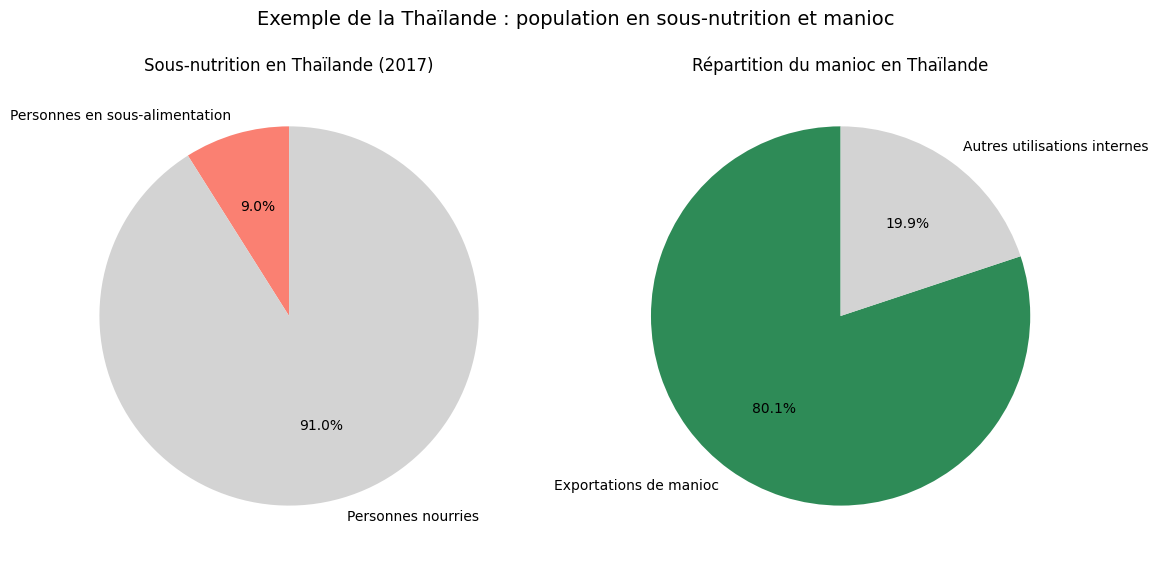

In [2682]:
import matplotlib.pyplot as plt

# =========================================================
# Graphique récapitulatif : sous-alimentation et manioc en Thaïlande
# =========================================================

# Données pour la population
pop_bien_nourrie = pop_thai_2017 - nb_sousnutri_thai

labels_pop = [
    "Personnes en sous-alimentation",
    "Personnes nourries"]
valeurs_pop = [
    nb_sousnutri_thai,
    pop_bien_nourrie]

# Données pour le manioc 
quantite_manioc_domestique = quantite_disponible_manioc - export_manioc

labels_manioc = [
    "Exportations de manioc",
    "Autres utilisations internes"]
valeurs_manioc = [
    export_manioc,
    quantite_manioc_domestique]

# Création des deux camemberts côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Camembert 1 : sous-alimentation
axes[0].pie(
    valeurs_pop,
    labels=labels_pop,
    autopct='%1.1f%%',
    startangle=90,
    colors=["salmon", "lightgrey"])
axes[0].set_title("Sous-nutrition en Thaïlande (2017)")

# Camembert 2 : manioc
axes[1].pie(
    valeurs_manioc,
    labels=labels_manioc,
    autopct='%1.1f%%',
    startangle=90,
    colors=["seagreen", "lightgrey"])
axes[1].set_title("Répartition du manioc en Thaïlande")

plt.suptitle("Exemple de la Thaïlande : population en sous-nutrition et manioc", fontsize=14)
plt.tight_layout()
plt.show()

In [2683]:
# Calcul de la disponibilité alimentaire par habitant pour la Thaïlande

# On (re)calcule le tableau de dispo énergétique par pays
dispo_kcal_pays = (
    df_dispo
    .groupby("Zone", as_index=False)["Disponibilité alimentaire (Kcal/personne/jour)"]
    .sum()
    .rename(columns={
        "Disponibilité alimentaire (Kcal/personne/jour)": "dispo_kcal_pers_jour"}))

# On récupère la valeur pour la Thaïlande
dispo_thai = (
    dispo_kcal_pays
    .loc[dispo_kcal_pays["Zone"] == "Thaïlande", "dispo_kcal_pers_jour"]
    .iloc[0])

print(
    f"Disponibilité alimentaire par habitant en Thaïlande (2017) : "
    f"{dispo_thai:.0f} kcal/personne/jour")

Disponibilité alimentaire par habitant en Thaïlande (2017) : 2785 kcal/personne/jour


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [2684]:
#ajouter en dessous toutes les analyses complémtaires

In [2685]:
#Analyse des inégalités alimentaires : Afrique et Asie

In [2686]:

# Analyse des inégalités alimentaires : Afrique et Asie
# Préparation des données de base


# Chargement sécurisé des données (au cas où)
try:
    df_dispo
except NameError:
    df_dispo = pd.read_csv("dispo_alimentaire.csv")

try:
    df_pop
except NameError:
    df_pop = pd.read_csv("population.csv")

try:
    df_sous
except NameError:
    df_sous = pd.read_csv("sous_nutrition.csv")

# Conversion de la dispo énergétique en numérique
df_dispo["Disponibilité alimentaire (Kcal/personne/jour)"] = pd.to_numeric(
    df_dispo["Disponibilité alimentaire (Kcal/personne/jour)"],
    errors="coerce").fillna(0)

# Agrégation de la dispo énergétique par pays
dispo_kcal_pays = (
    df_dispo
    .groupby("Zone", as_index=False)["Disponibilité alimentaire (Kcal/personne/jour)"].sum())

# Conversion des valeurs de sous-nutrition en numérique
df_sous["Valeur"] = pd.to_numeric(df_sous["Valeur"], errors="coerce")


In [2687]:

# Fonction : préparer les indicateurs pour une liste de pays

def preparer_indicateurs_pays(liste_pays):
    lignes = []
    
    for pays in liste_pays:
        # Population 2017 (en personnes)
        pop_row = df_pop[(df_pop["Zone"] == pays) & (df_pop["Année"] == 2017)]
        if pop_row.empty:
            continue
        pop_total = pop_row["Valeur"].iloc[0] * 1_000      # milliers -> personnes
        pop_millions = pop_total / 1_000_000
        
        # Sous-nutrition (intervalle 2016-2018, en millions de personnes)
        sous_row = df_sous[(df_sous["Zone"] == pays) & (df_sous["Année"] == "2016-2018")]
        if sous_row.empty:
            nb_sous = np.nan
            taux_sous = np.nan
        else:
            sous_millions = sous_row["Valeur"].iloc[0]     # déjà en millions
            nb_sous = sous_millions * 1_000_000
            taux_sous = nb_sous / pop_total * 100
        
        # Disponibilité énergétique (kcal/personne/jour)
        dispo_row = dispo_kcal_pays[dispo_kcal_pays["Zone"] == pays]
        if dispo_row.empty:
            dispo_kcal = np.nan
        else:
            dispo_kcal = dispo_row["Disponibilité alimentaire (Kcal/personne/jour)"].iloc[0]
        
        lignes.append({
            "Zone": pays,
            "pop_millions": pop_millions,
            "taux_sous_nutri": taux_sous,
            "dispo_kcal": dispo_kcal})
    
    return pd.DataFrame(lignes)


In [2688]:
# Fonction : créer le graphique barres + double axe Y

def tracer_sousnutri_dispo(df, titre):
    x = np.arange(len(df))
    largeur = 0.35
    
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Barres bleues : % sous-nutrition
    barres1 = ax1.bar(
        x - largeur/2,
        df["taux_sous_nutri"],
        largeur,
        label="% sous-nutrition")
    ax1.set_ylabel("% de la population en sous-nutrition")
    ax1.set_xticks(x)
    ax1.set_xticklabels(df["Zone"])
    
    # Echelle de gauche (pourcentage)
    ax1.set_ylim(0, df["taux_sous_nutri"].max() * 1.3)
    
    # Deuxième axe Y : dispo énergétique
    ax2 = ax1.twinx()
    barres2 = ax2.bar(
        x + largeur/2,
        df["dispo_kcal"],
        largeur,
        label="Disponibilité énergétique (kcal)",
        color="orange")
    
    ax2.set_ylabel("Disponibilité énergétique (kcal/personne/jour)")
    
    # Echelle de droite (kcal)
    ax2.set_ylim(df["dispo_kcal"].min() * 0.95, df["dispo_kcal"].max() * 1.05)
    
    # Titre général
    fig.suptitle(titre, fontsize=14)
    
    # Ajout des annotations sur les barres
    for rect, taux, popM in zip(barres1, df["taux_sous_nutri"], df["pop_millions"]):
        hauteur = rect.get_height()
        ax1.text(
            rect.get_x() + rect.get_width()/2,
            hauteur + 0.2,
            f"{taux:.2f}%\nPop: {popM:.1f} M",
            ha="center",
            va="bottom",
            fontsize=9)
    
    for rect, kcal in zip(barres2, df["dispo_kcal"]):
        hauteur = rect.get_height()
        ax2.text(
            rect.get_x() + rect.get_width()/2,
            hauteur + 5,
            f"{int(kcal)} kcal",
            ha="center",
            va="bottom",
            fontsize=9        )
    
    # Légende combinée des deux axes
    lignes1, labels1 = ax1.get_legend_handles_labels()
    lignes2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lignes1 + lignes2, labels1 + labels2, loc="upper right")
    
    plt.tight_layout()
    plt.show()


,Zone,pop_millions,taux_sous_nutri,dispo_kcal
0,Thaïlande,69.209810,8.958268,2785.0
1,Viet Nam,94.600648,6.870989,2744.0
2,Indonésie,264.650963,8.917406,2776.0


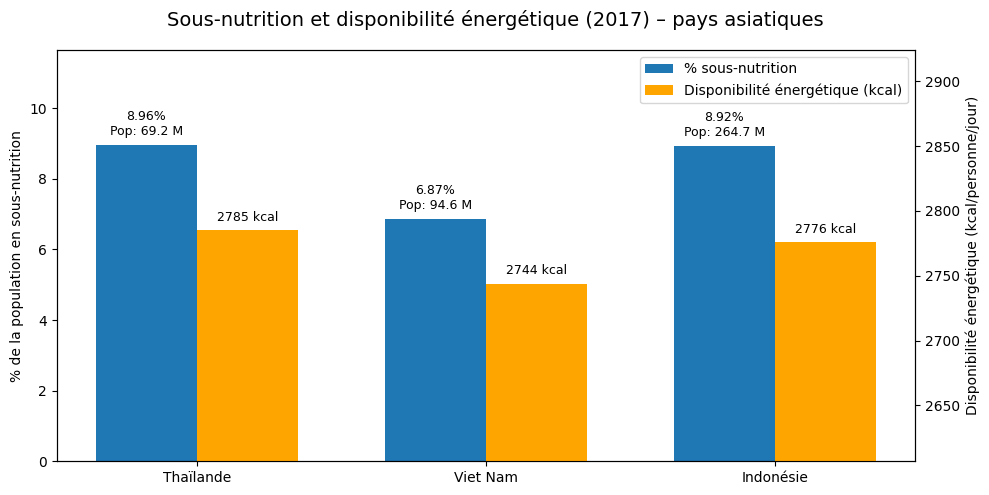

In [2689]:
# Analyse des inégalités alimentaires : pays asiatiques

# Pays choisis 
pays_asiatiques = ["Thaïlande", "Viet Nam", "Indonésie"]

df_asie = preparer_indicateurs_pays(pays_asiatiques)
display(df_asie)

tracer_sousnutri_dispo(
    df_asie,
    "Sous-nutrition et disponibilité énergétique (2017) – pays asiatiques")

,Zone,pop_millions,taux_sous_nutri,dispo_kcal
0,Éthiopie,106.399924,19.830841,2129.0
1,Zambie,16.853599,NaN,1924.0
2,République centrafricaine,4.596023,NaN,1879.0


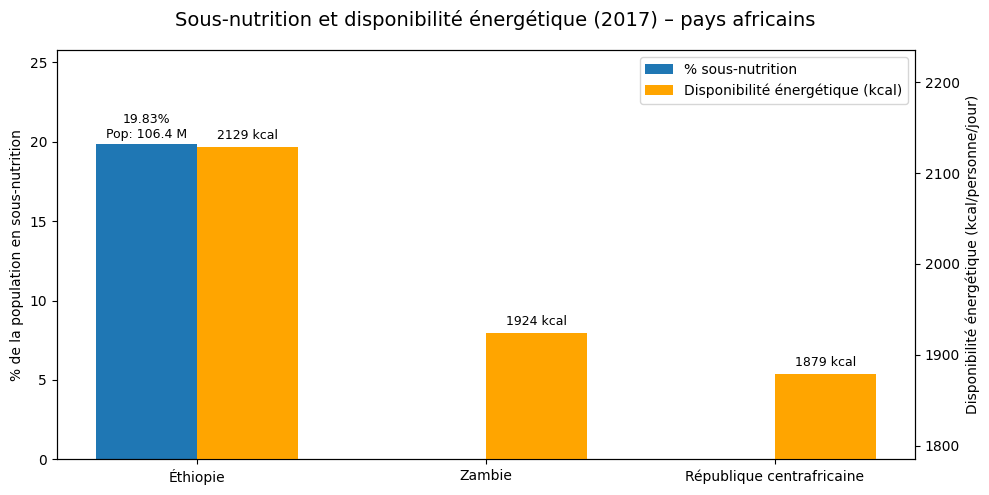

In [2690]:
# Analyse des inégalités alimentaires : pays africains

pays_africains = ["Éthiopie", "Zambie", "République centrafricaine"]

df_afrique = preparer_indicateurs_pays(pays_africains)
display(df_afrique)

tracer_sousnutri_dispo(
    df_afrique,
    "Sous-nutrition et disponibilité énergétique (2017) – pays africains")

In [2691]:
import sys
print(sys.executable)
print(sys.version)


c:\Users\Joana Aubry\projetos_python312\.venv\Scripts\python.exe
3.12.9 (tags/v3.12.9:fdb8142, Feb  4 2025, 15:27:58) [MSC v.1942 64 bit (AMD64)]


In [2692]:
import pandas as pd
import matplotlib
print(pd.__version__)
print(matplotlib.__version__)

2.3.3
3.10.7


In [2693]:
# ================================
# Analyse complémentaires
# ================================

import sys
import pandas as pd
import matplotlib

In [2694]:
# 1) Vérification de l'environnement Python
print("Exécutable Python :", sys.executable)
print("Version Python :", sys.version)


Exécutable Python : c:\Users\Joana Aubry\projetos_python312\.venv\Scripts\python.exe
Version Python : 3.12.9 (tags/v3.12.9:fdb8142, Feb  4 2025, 15:27:58) [MSC v.1942 64 bit (AMD64)]


In [2695]:
# 2) Vérification des versions des bibliothèques principales
print("Version pandas :", pd.__version__)
print("Version matplotlib :", matplotlib.__version__)


Version pandas : 2.3.3
Version matplotlib : 3.10.7


In [2696]:
# 3) Vérification des colonnes disponibles dans les principaux dataframes
print("Colonnes dispo_alimentaire :", dispo_alimentaire.columns.tolist())
print("Colonnes sous_nutrition :", sous_nutrition.columns.tolist())
print("Colonnes population :", population.columns.tolist())


Colonnes dispo_alimentaire : ['Zone', 'Produit', 'Origine', 'Aliments pour animaux', 'Autres Utilisations', 'dispo_kcal', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité de matière grasse en quantité (g/personne/jour)', 'Disponibilité de protéines en quantité (g/personne/jour)', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Nourriture', 'Pertes', 'Production', 'Semences', 'Traitement', 'Variation de stock']
Colonnes sous_nutrition : ['Zone', 'Année', 'Valeur']
Colonnes population : ['Zone', 'Année', 'Valeur']


In [2697]:
# 4) Statistiques rapides pour valider les données
print("Résumé dispo_alimentaire :")
print(dispo_alimentaire.describe(include="all"))

Résumé dispo_alimentaire :
         Zone           Produit   Origine  Aliments pour animaux  \
count   15605             15605     15605           1.560500e+04   
unique    174                98         2                    NaN   
top      Inde  Abats Comestible  vegetale                    NaN   
freq       97               174     11896                    NaN   
mean      NaN               NaN       NaN           8.357866e+07   
std       NaN               NaN       NaN           1.779289e+09   
min       NaN               NaN       NaN           0.000000e+00   
25%       NaN               NaN       NaN           0.000000e+00   
50%       NaN               NaN       NaN           0.000000e+00   
75%       NaN               NaN       NaN           0.000000e+00   
max       NaN               NaN       NaN           1.500000e+11   

        Autres Utilisations    dispo_kcal  \
count          1.560500e+04  15605.000000   
unique                  NaN           NaN   
top                  

In [2698]:
print("Résumé sous_nutrition :")
print(sous_nutrition.describe(include="all"))



Résumé sous_nutrition :
               Zone      Année Valeur
count          1218       1218    624
unique          203          6    139
top     Afghanistan  2012-2014   <0.1
freq              6        203    120


In [2699]:
print("Résumé population :")
print(population.describe(include="all"))

Résumé population :
               Zone        Année        Valeur
count          1416  1416.000000  1.416000e+03
unique          236          NaN           NaN
top     Afghanistan          NaN           NaN
freq              6          NaN           NaN
mean            NaN  2015.500000  3.144793e+04
std             NaN     1.708428  1.300812e+05
min             NaN  2013.000000  7.930000e-01
25%             NaN  2014.000000  3.783410e+02
50%             NaN  2015.500000  5.126480e+03
75%             NaN  2017.000000  1.930666e+04
max             NaN  2018.000000  1.427648e+06


In [2700]:
print("Résumé aide_alimentaire :")
print(aide_alimentaire.describe(include="all"))

Résumé aide_alimentaire :
       Pays bénéficiaire        Année       Produit         Valeur
count               1475  1475.000000          1475    1475.000000
unique                76          NaN            16            NaN
top              Algérie          NaN  Non-céréales            NaN
freq                  39          NaN           220            NaN
mean                 NaN  2014.054237           NaN    7481.966780
std                  NaN     0.946916           NaN   23339.531424
min                  NaN  2013.000000           NaN       0.000000
25%                  NaN  2013.000000           NaN     287.500000
50%                  NaN  2014.000000           NaN    1178.000000
75%                  NaN  2015.000000           NaN    4334.500000
max                  NaN  2016.000000           NaN  265013.000000


In [2701]:
pip install nbconvert

Note: you may need to restart the kernel to use updated packages.
